# Name : Stéphane EILLES-CHAN WAY

# Reinforcement Learning Programming Assignment

## MinAtar: Learning to Play Atari-Style Games

This assignment asks you to design, implement, and analyze reinforcement learning algorithms on MinAtar, a set of simplified Atari-style environments. MinAtar provides the visual complexity of Atari games at reduced computational cost: observations are 10×10 pixel grids with a small number of channels, and episodes run faster than their full-scale counterparts.

You will work primarily with **Breakout**, then test whether your methods transfer to other MinAtar games.

### Objectives

By the end of this assignment, you should be able to:

- Analyze an RL environment: state space, action space, reward structure, and episode dynamics
- Select and justify appropriate state representations for learning
- Implement at least two RL algorithms: one classical, one using neural networks
- Interpret learned policies through visualization and quantitative analysis
- Diagnose training issues and apply techniques to address them
- Evaluate generalization across different environments

### Deliverables

Submit a single Jupyter notebook that serves as both your implementation and your report. Your notebook should:

1. **Run end-to-end** without errors
2. **Document your approach** with clear explanations in markdown cells
3. **Present results** with well-labeled figures and tables
4. **Analyze findings** with interpretation of what works, what fails, and why

### Rules

- **Implement RL algorithms yourself.** Do not use RL libraries (stable-baselines, RLlib, CleanRL, etc.)
- **Standard libraries are allowed.** PyTorch, NumPy, scikit-learn, matplotlib, and similar tools are permitted.
- **Cite your sources.** If you adapt an algorithm from a paper or other resource, reference it.

# Sources

Tabular Q-learning: 

Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. Machine Learning, 8, 279–292.  ￼

Deep Q-Learning: 

Mnih, V., et al. (2015). Human-level control through deep reinforcement learning. Nature, 518, 529–533.  ￼

Double DQN: 

van Hasselt, H., Guez, A., & Silver, D. (2016). Deep Reinforcement Learning with Double Q-learning. (arXiv preprint / AAAI).  ￼

---
## Part 0: Environment and Baselines

The code below sets up the MinAtar Breakout environment and provides two baseline policies for comparison:

- **Random policy**: selects actions uniformly at random
- **Heuristic policy**: moves the paddle toward the ball's horizontal position


In [1]:
!pip install numpy gymnasium minatar torch

Defaulting to user installation because normal site-packages is not writeable
  Using cached gymnasium-1.1.1-py3-none-any.whl (965 kB)
  Using cached MinAtar-1.0.15-py3-none-any.whl (16 kB)
     |████████████████████████████████| 888.0 MB 1.4 kB/s              
     |████████████████████████████████| 44 kB 2.7 MB/s             
     |████████████████████████████████| 12.8 MB 52.1 MB/s            
     |████████████████████████████████| 294 kB 71.7 MB/s            
     |████████████████████████████████| 509 kB 60.1 MB/s            
     |████████████████████████████████| 200 kB 35.6 MB/s            
     |████████████████████████████████| 1.6 MB 46.4 MB/s            
     |████████████████████████████████| 288.2 MB 4.9 kB/s              
     |████████████████████████████████| 322.4 MB 27 kB/s              
     |████████████████████████████████| 954 kB 31.2 MB/s            
     |████████████████████████████████| 155.4 MB 50 kB/s              
     |████████████████████████████████| 1

In [3]:
import numpy as np
import torch
import gymnasium as gym
from minatar import Environment
from minatar.gym import register_envs

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

if "MinAtar/Breakout-v1" not in gym.envs.registry:
    register_envs()

In [4]:
def random_policy(observation, num_actions):
    return np.random.randint(num_actions)

In [5]:
def breakout_heuristic_policy(observation, num_actions):
    paddle_channel = observation[:, :, 0]
    ball_channel = observation[:, :, 1]

    paddle_pos = np.where(paddle_channel == 1)
    ball_pos = np.where(ball_channel == 1)

    if len(paddle_pos[1]) == 0 or len(ball_pos[1]) == 0:
        return 0

    paddle_x = paddle_pos[1].mean()
    ball_x = ball_pos[1].mean()

    if ball_x < paddle_x:
        return 1
    elif ball_x > paddle_x:
        return 2
    else:
        return 0

In [6]:
def run_episode(env, policy_fn):
    observation, info = env.reset()
    num_actions = env.action_space.n

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated):
        action = policy_fn(observation, num_actions)
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    return total_reward, steps


def evaluate_policy(env, policy_fn, num_episodes=100):
    rewards = []
    steps_list = []

    for _ in range(num_episodes):
        total_reward, steps = run_episode(env, policy_fn)
        rewards.append(total_reward)
        steps_list.append(steps)

    return np.array(rewards), np.array(steps_list)

In [7]:
env = gym.make("MinAtar/Breakout-v1")
env.reset()

print(f"Observation shape: {env.observation_space.shape}")
print(f"Number of actions: {env.action_space.n}")

Observation shape: (10, 10, 4)
Number of actions: 3


In [8]:
num_episodes = 100

random_rewards, random_steps = evaluate_policy(env, random_policy, num_episodes)
print(f"Random Policy:")
print(f"  Reward: {random_rewards.mean():.2f} +/- {random_rewards.std():.2f}")
print(f"  Steps:  {random_steps.mean():.2f} +/- {random_steps.std():.2f}")

heuristic_rewards, heuristic_steps = evaluate_policy(env, breakout_heuristic_policy, num_episodes)
print(f"\nHeuristic Policy:")
print(f"  Reward: {heuristic_rewards.mean():.2f} +/- {heuristic_rewards.std():.2f}")
print(f"  Steps:  {heuristic_steps.mean():.2f} +/- {heuristic_steps.std():.2f}")

Random Policy:
  Reward: 0.33 +/- 0.53
  Steps:  9.34 +/- 5.43

Heuristic Policy:
  Reward: 8.60 +/- 9.67
  Steps:  100.88 +/- 111.88


In [9]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML


def render_frame(env):
    frame = env.render()
    return (frame * 255).astype(np.uint8)


def run_episode_with_frames(env, policy_fn, max_steps=500):
    observation, info = env.reset()
    num_actions = env.action_space.n
    frames = [render_frame(env)]

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(observation, num_actions)
        observation, reward, terminated, truncated, info = env.step(action)
        frames.append(render_frame(env))
        total_reward += reward
        steps += 1

    return frames, total_reward, steps


def animate_episode(frames, interval=50):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.axis("off")
    img = ax.imshow(frames[0], interpolation="nearest")

    def update(frame):
        img.set_array(frame)
        return [img]

    anim = animation.FuncAnimation(
        fig, update, frames=frames, interval=interval, blit=True
    )
    plt.close(fig)
    return anim


env_visual = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array", disable_env_checker=True)
env_visual.reset()

frames, reward, steps = run_episode_with_frames(env_visual, breakout_heuristic_policy)
print(f"Episode: Reward = {reward}, Steps = {steps}")

anim = animate_episode(frames, interval=100)
HTML(anim.to_jshtml())

Episode: Reward = 24, Steps = 282


---

## Part 1: Environment Analysis [5 marks]

Before designing learning algorithms, you must understand the environment.

### Questions to Address

1. **State space**: What is the shape of the observations? What does each channel represent? How many unique states are theoretically possible?

2. **Action space**: What actions are available? How do they affect the game state?

3. **Reward structure**: When and how frequently does the agent receive rewards? What is the typical range of episode returns?

4. **Episode dynamics**: What causes an episode to terminate? What is the distribution of episode lengths under the random and heuristic policies?

5. **Stochasticity**: Is the environment deterministic or stochastic? If stochastic, what are the sources of randomness?

Visualize observations, reward distributions, and episode statistics to support your analysis.

To answer these questions, we used the article and the documentation of the MinAtar environment :
- documentation : https://www.sotets.uk/pgx/minatar_breakout/
- article : https://arxiv.org/pdf/1903.03176

### Answer to Question 1: State Space
The shape of the observations is (10, 10, 4), where the first two dimensions represent the grid (10x10 pixels) and the third dimension represents the four channels. The first channel represents the paddle, the second channel represents the ball, the third channel represents the trail of the ball, and the fourth channel represents the bricks.

Each channel is a binary matrix indicating the presence of that element in each pixel. Therefore, the number of unique states is theoretically $2^{10\times10\times 4} = 2^{400}$. However, not all of these states are valid or reachable due to the game dynamics and constraints, so the effective state space is much smaller.

### Answer to Question 2: Action Space
The action space consists of 3 discrete actions: no-op (0), move left (1), and move right (2). These actions affect the game state by moving the paddle horizontally. The "no-op" action keeps the paddle in its current position, while "move left" and "move right" shift the paddle one pixel in the respective direction.

### Answer to Question 3: Reward Structure

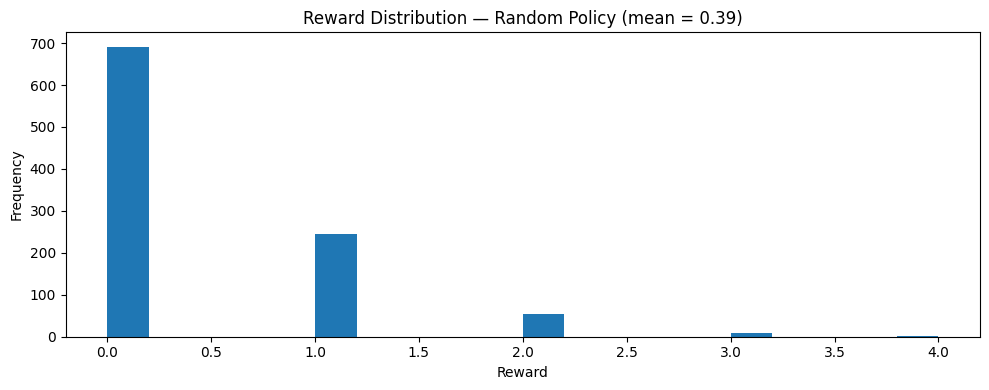

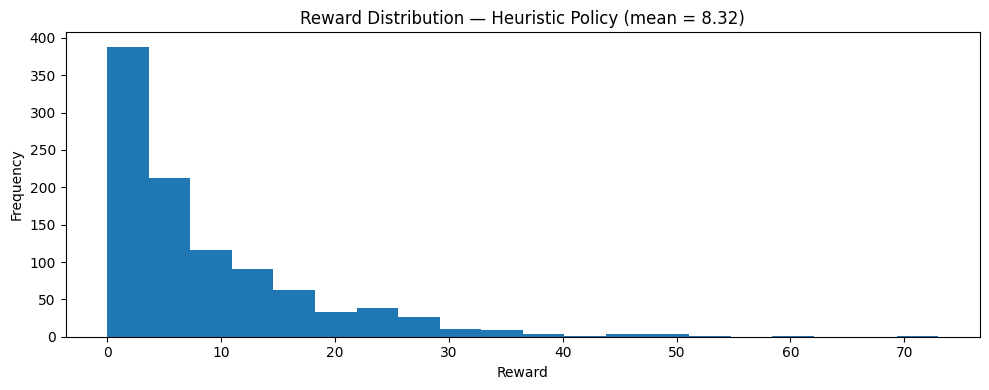

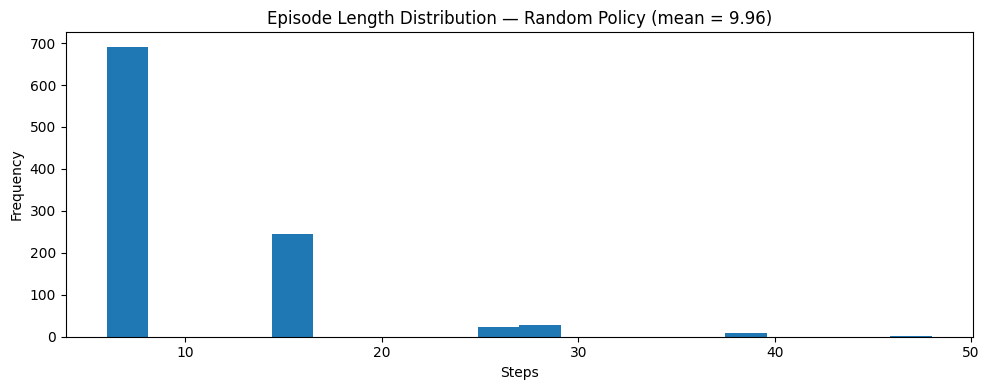

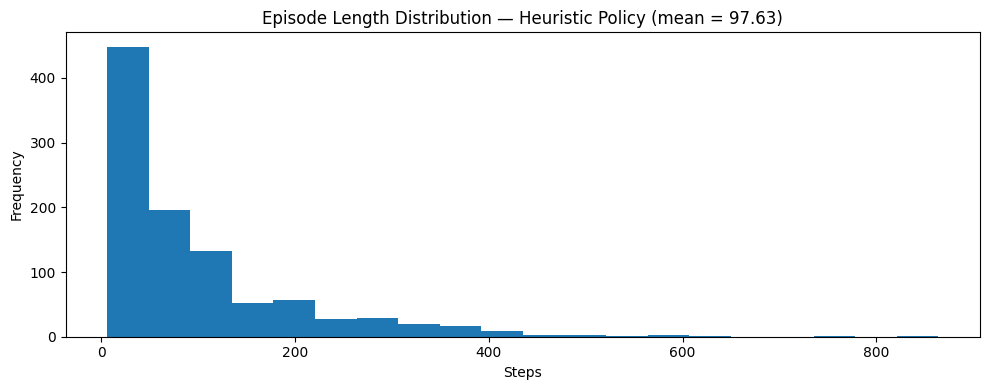

In [10]:
num_episodes = 1000

random_rewards, random_steps = evaluate_policy(env, random_policy, num_episodes)
heuristic_rewards, heuristic_steps = evaluate_policy(env, breakout_heuristic_policy, num_episodes)

def plot_distribution(values, title, xlabel, bins=20):
    mean_val = float(values.mean())
    plt.figure(figsize=(10, 4))
    plt.hist(values, bins=bins) 
    plt.title(f"{title} (mean = {mean_val:.2f})")
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

plot_distribution(random_rewards,    "Reward Distribution — Random Policy",    "Reward")
plot_distribution(heuristic_rewards, "Reward Distribution — Heuristic Policy", "Reward")

plot_distribution(random_steps,      "Episode Length Distribution — Random Policy",    "Steps")
plot_distribution(heuristic_steps,   "Episode Length Distribution — Heuristic Policy", "Steps")

The agent receives a reward of +1 for each brick it successfully hits with the ball. The rewards are sparse, as they only occur when the ball hits a brick. 

The typical range of episode returns can vary widely depending on the policy used. Under the random policy, the average return is $0.4$ in a range of $[0, 4]$, while the heuristic policy achieves an average return of $8.4$ in a range of $[0, 60]$.

### Answer to Question 4: Episode Dynamics
An episode terminates when the ball falls below the paddle (when the player misses the ball).

Under the random policy, the distribution of episode lengths is heavily concentrated at shorter episodes, with a mean length of around 10 steps. In contrast, the heuristic policy results in a wider distribution of episode lengths, with a mean length of around 100 steps, indicating that it is more effective at keeping the ball in play.

### Answer to Question 5: Stochasticity

In [11]:
start_positions = []

for i in range(5):
    obs, info = env.reset(seed=i)  # different seeds -> potentially different initial states

    # Ball position
    ball_map = obs[:, :, 1]
    ys, xs = np.where(ball_map == 1)

    y, x = int(ys[0]), int(xs[0])
    start_positions.append((y, x))
    print(f"Reset {i}: ball start position = (y={y}, x={x})")

    # Ball trail at reset
    trail_positions_over_time = []

    for t in range(3):  # small rollout to observe trail changes
        trail_map = obs[:, :, 2]
        tys, txs = np.where(trail_map == 1)

        # Store all trail cells
        trail_cells = list(zip(tys.tolist(), txs.tolist()))
        trail_positions_over_time.append(trail_cells)

        # Take a random action just to advance the environment
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
            break

    print(f"  Trail over time (up to {len(trail_positions_over_time)} steps):")
    for t, cells in enumerate(trail_positions_over_time):
        print(f"    t={t}: {cells}")

# Show unique positions observed
unique_positions = set(p for p in start_positions if p is not None)
print("\nUnique start positions observed:", unique_positions)

Reset 0: ball start position = (y=3, x=0)
  Trail over time (up to 3 steps):
    t=0: [(3, 0)]
    t=1: [(3, 0)]
    t=2: [(4, 1)]
Reset 1: ball start position = (y=3, x=9)
  Trail over time (up to 3 steps):
    t=0: [(3, 9)]
    t=1: [(3, 9)]
    t=2: [(4, 8)]
Reset 2: ball start position = (y=3, x=0)
  Trail over time (up to 3 steps):
    t=0: [(3, 0)]
    t=1: [(3, 0)]
    t=2: [(4, 1)]
Reset 3: ball start position = (y=3, x=0)
  Trail over time (up to 3 steps):
    t=0: [(3, 0)]
    t=1: [(3, 0)]
    t=2: [(4, 1)]
Reset 4: ball start position = (y=3, x=0)
  Trail over time (up to 3 steps):
    t=0: [(3, 0)]
    t=1: [(3, 0)]
    t=2: [(4, 1)]

Unique start positions observed: {(3, 9), (3, 0)}


The environment is stochastic due to the random initial placement of the ball. According to our observations the ball is initialized in different positions across multiple resets and the dynamics seems to depend on the initial conditions. Otherwise, the environment is deterministic, as the same sequence of actions from the same initial state will always yield the same trajectory and rewards.

---

## Part 2: A Classical RL Method [8 marks]

Implement a reinforcement learning algorithm that does not use neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm given your analysis of the state space
- Choose an appropriate state representation
- Justify your choices based on the environment properties you identified in Part 1

### Questions to Address

1. **State representation**: How do you represent the state? Why is this representation appropriate for your chosen algorithm?

2. **Algorithm description**: What algorithm did you implement? Write out the update rules.

3. **Hyperparameters**: What hyperparameters does your method have? How did you select their values?

4. **Learning curves**: Plot the return during training. Include error bars or confidence intervals if you run multiple seeds.

5. **Comparison to baselines**: How does your trained policy compare to the random and heuristic baselines?

### Answer to Question 1: State Representation
Even if the observations are binary, they are matrices of size 10x10 with 4 channels, which is very high dimensional. To make the state representation more manageable for a classical RL algorithm, we can use a simplified representation that captures the essential information about the game state. 

We propose to represent the state as a tuple containing :
- x_rel : the horizontal position of the paddle relative to the ball (mean of the channel 0 minus mean of the channel 1). This is motivated by the fact that only the relative position of the paddle to the ball matters for the decision making, and it reduces the state space significantly.
- y_ball : the vertical position of the ball (channel 1)
- dx, dy : the velocity of the ball (estimated with the trail in channel 2)

For the moment, we will not include the bricks in the state representation, as we want to focus on learning to keep the ball in play and hit the bricks, rather than learning to model the brick configuration. Besides, it reduce the state space and make it more tractable for a classical RL algorithm.

### Answer to Question 2: Algorithm Description
Since the action space is discrete and the state space is manageable, we implemented a tabular Q-learning algorithm. The update rule for Q-learning is given by:
$$Q(x_t, a_t) \leftarrow Q(x_t, a_t) + \alpha \left[r_t + \gamma \max_{b} Q(x_{t+1}, b) - Q(x_t, a_t)\right]$$
where $x_t$ is the current state, $a_t$ is the action taken, $r_t$ is the reward received, $x_{t+1}$ is the next state, $\alpha$ is the learning rate, and $\gamma$ is the discount factor.

In [12]:
from collections import defaultdict

class QLearningAgent:
    def __init__(self, action_space_n = 3, alpha=0.1, gamma=0.99, epsilon=1.0, epsilon_decay=0.99, min_epsilon=0.01):
        self.action_space_n = action_space_n
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.q_table = defaultdict(lambda: np.zeros(self.action_space_n))

    def get_state(self, observation):
        paddle_channel = observation[:, :, 0]
        ball_channel = observation[:, :, 1]

        y_paddle, x_paddle = np.where(paddle_channel == 1)
        y_ball, x_ball = np.where(ball_channel == 1)

        if len(y_paddle) == 0:
            paddle_x = 5
        else:
            paddle_x = int(x_paddle.mean())
        
        if len(x_ball) == 0:
            return (-1, 0, 0, 0)
        
        trail_y, trail_x = np.where(observation[:, :, 2] == 1)
        if len(trail_x) == 0:
            dx, dy = 0, 0
        else:
            dx = int(x_ball[0] - trail_x[0])
            dy = int(y_ball[0] - trail_y[0])

        x_rel = int(paddle_x - x_ball[0])
        return (x_rel, y_ball[0], dx, dy)
    
    def select_action(self, state, evaluate=False):
        if np.random.rand() < self.epsilon and not evaluate:
            return np.random.randint(self.action_space_n)
        else:
            q_values = self.q_table[state]
            max_q = np.max(q_values)
            actions_with_max_q = np.where(q_values == max_q)[0]
            return np.random.choice(actions_with_max_q)
    
    def update(self, state, action, reward, next_state, done):
        current_q = self.q_table[state][action]
        max_next_q = np.max(self.q_table[next_state]) if not done else 0
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
    
    def train(self, env, num_episodes=1000, max_steps=5000, verbose=True):
        rewards = []
        for episode in range(num_episodes):
            observation, info = env.reset()
            state = self.get_state(observation)
            total_reward = 0
            terminated = False
            truncated = False

            for step in range(max_steps):
                action = self.select_action(state)
                next_observation, reward, terminated, truncated, info = env.step(action)
                next_state = self.get_state(next_observation)

                self.update(state, action, reward, next_state, terminated or truncated)
                state = next_state
                total_reward += reward

                if terminated or truncated:
                    break
            
            self.decay_epsilon()
            rewards.append(total_reward)
            if (episode + 1) % 100 == 0 and verbose:
                    print(f"Episode {episode+1}/{num_episodes}, Mean Reward (last 100): {np.mean(rewards[-100:]):.2f}, Epsilon: {self.epsilon:.2f}")

        return rewards
    
    def evaluate(self, env, num_episodes=100):
        rewards = []
        steps = []
        frames = []
        for episode in range(num_episodes):
            observation, info = env.reset()
            state = self.get_state(observation)
            total_reward = 0
            terminated = False
            truncated = False
            step = 0

            while not (terminated or truncated):
                step += 1
                action = self.select_action(state, evaluate=True)
                next_observation, reward, terminated, truncated, info = env.step(action)
                next_state = self.get_state(next_observation)

                state = next_state
                total_reward += reward

            rewards.append(total_reward)
            steps.append(step)
        return rewards, steps
    
    def run_episode(self, env, render=False):
        observation, info = env.reset()
        state = self.get_state(observation)
        total_reward = 0
        terminated = False
        truncated = False
        frames = [render_frame(env)] if render else []

        while not (terminated or truncated):
            action = self.select_action(state, evaluate=True)
            next_observation, reward, terminated, truncated, info = env.step(action)
            next_state = self.get_state(next_observation)

            state = next_state
            total_reward += reward

            if render:
                frame = render_frame(env)
                frames.append(frame)

        return total_reward, frames

First test of the algorithm, without tuning the hyperparameters.

Evaluation over 1000 episodes: Mean Reward = 3.73 +/- 1.89
Average steps per episode: 45.16


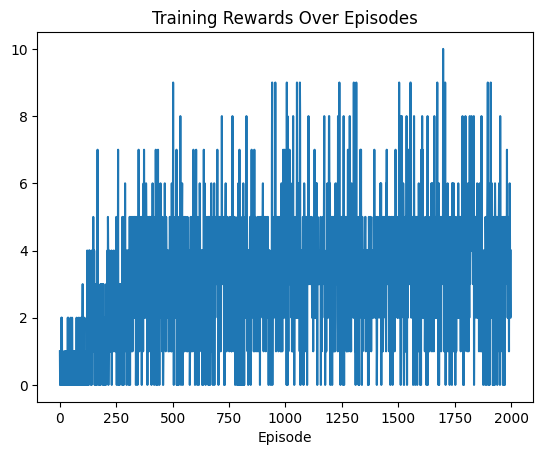

In [14]:
num_episodes = 2000
agent = QLearningAgent()
training_rewards = agent.train(env, num_episodes=num_episodes, verbose=False)

plt.plot(training_rewards)
plt.title("Training Rewards Over Episodes")
plt.xlabel("Episode")   

rewards, steps = agent.evaluate(env, num_episodes=1000)
print(f"Evaluation over 1000 episodes: Mean Reward = {np.mean(rewards):.2f} +/- {np.std(rewards):.2f}")
print(f"Average steps per episode: {np.mean(steps):.2f}")

In [15]:
reward, frames = agent.run_episode(env_visual, render=True)
print(f"Test Episode: Reward = {reward}")
anim = animate_episode(frames, interval=100)
HTML(anim.to_jshtml())

Test Episode: Reward = 4


### Answer to Question 3: Hyperparameters
The main hyperparameters of the Q-learning algorithm are the learning rate $\alpha$, the discount factor $\gamma$, and the exploration rate $\epsilon$ for the epsilon-greedy policy.

At the beginning, we set $\epsilon$ to 1.0 and decay it over time to encourage exploration in the early stages of training and exploitation in the later stages. However, we select $ \alpha $, $ \gamma $, and $ \epsilon_{decay} $ with a simple grid search approach.

In [16]:
import itertools
def run_grid_search():
    # define the environment
    env = gym.make("MinAtar/Breakout-v1")
    
    # define the hyperparameter grid  
    param_grid = {
        'alpha': [0.01, 0.1, 0.2, 0.3, 0.5],          
        'gamma': [0.99, 0.95, 0.9, 0.8],                   
        'epsilon_decay': [0.9, 0.95, 0.99, 0.995]
    }
    
    # create all combinations of hyperparameters
    keys, values = zip(*param_grid.items())
    param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    print(f"Beginning of the grid search over {len(param_combinations)} combinations...")
    print("-" * 50)
    
    best_score = -np.inf
    best_params = None
    results = []

    for i, params in enumerate(param_combinations):
        print(f"Test {i+1}/{len(param_combinations)}: {params}")
        
        # Initialization of the agent with current parameters
        agent = QLearningAgent(
            action_space_n=env.action_space.n,
            alpha=params['alpha'],
            gamma=params['gamma'],
            epsilon_decay=params['epsilon_decay'],
            epsilon=1.0 # allways start with 100% exploration
        )
        
        # training
        train_rewards = agent.train(env, num_episodes=1000, verbose=False)
        
        eval_rewards, eval_steps = agent.evaluate(env, num_episodes=500)
        mean_score = np.mean(eval_rewards)
        
        # evaluation
        print(f"  -> Mean score: {mean_score:.2f}")
        
        # Save the results
        results.append({
            'params': params,
            'score': mean_score,
            'steps': np.mean(eval_steps),
            'train_curve': train_rewards
        })
        
        # Update best score and params if current is better
        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            print(f"  -> new best score found: {best_score:.2f} with params: {best_params}")

    print("-" * 50)
    print("Grid Search completed.")
    print(f"Best parameters found: {best_params}")
    print(f"Best average score: {best_score:.2f}")
    
    return best_params, results

best_params, all_results = run_grid_search()

Beginning of the grid search over 80 combinations...
--------------------------------------------------
Test 1/80: {'alpha': 0.01, 'gamma': 0.99, 'epsilon_decay': 0.9}
  -> Mean score: 2.99
  -> new best score found: 2.99 with params: {'alpha': 0.01, 'gamma': 0.99, 'epsilon_decay': 0.9}
Test 2/80: {'alpha': 0.01, 'gamma': 0.99, 'epsilon_decay': 0.95}
  -> Mean score: 2.29
Test 3/80: {'alpha': 0.01, 'gamma': 0.99, 'epsilon_decay': 0.99}
  -> Mean score: 3.32
  -> new best score found: 3.32 with params: {'alpha': 0.01, 'gamma': 0.99, 'epsilon_decay': 0.99}
Test 4/80: {'alpha': 0.01, 'gamma': 0.99, 'epsilon_decay': 0.995}
  -> Mean score: 2.84
Test 5/80: {'alpha': 0.01, 'gamma': 0.95, 'epsilon_decay': 0.9}
  -> Mean score: 5.33
  -> new best score found: 5.33 with params: {'alpha': 0.01, 'gamma': 0.95, 'epsilon_decay': 0.9}
Test 6/80: {'alpha': 0.01, 'gamma': 0.95, 'epsilon_decay': 0.95}
  -> Mean score: 3.14
Test 7/80: {'alpha': 0.01, 'gamma': 0.95, 'epsilon_decay': 0.99}
  -> Mean score

Finally, based on the grid search, we found that the best hyperparameters are $\alpha = 0.5$, $\gamma = 0.9$, and $\epsilon_{decay} = 0.995$.

### Answer to Question 4: Learning Curves


In [18]:
seeds = [0, 1, 2, 3, 4]
num_episodes = 2500
rewards = np.zeros((len(seeds), num_episodes)) 

for i, seed in enumerate(seeds):
    print(f"Running seed {seed} ({i+1}/{len(seeds)})")

    env = gym.make("MinAtar/Breakout-v1", disable_env_checker=True)

    # Seed the environment and action space
    env.action_space.seed(seed)
    env.reset(seed=seed)

    # seed the random number generators 
    np.random.seed(seed)

    agent = QLearningAgent(
        action_space_n=env.action_space.n,
        alpha=0.5,
        gamma=0.9,
        epsilon=1.0,
        epsilon_decay=0.995,
        min_epsilon=0.01,
    )

    rewards[i, :] = agent.train(env, num_episodes=num_episodes, verbose=False)

    env.close()


Running seed 0 (1/5)
Running seed 1 (2/5)
Running seed 2 (3/5)
Running seed 3 (4/5)
Running seed 4 (5/5)


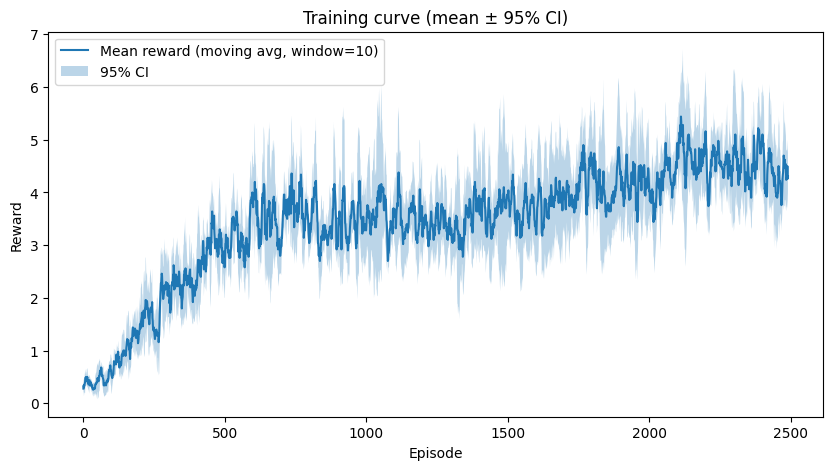

In [19]:
def smooth_rewards(rewards, window=5):
    if window <= 1:
        return rewards
    def moving_average_1d(x, window=window):
        if window <= 1:
            return x
        kernel = np.ones(window) / window
        return np.convolve(x, kernel, mode="valid")

    return np.stack([moving_average_1d(r, window) for r in rewards], axis=0)

def plot_training_curve_with_ci(rewards, smooth_window=5, title="Training curve (mean ± 95% CI)"):
    rewards_sm = smooth_rewards(rewards, window=smooth_window)
    n_seeds = rewards_sm.shape[0]

    mean = rewards_sm.mean(axis=0)
    std = rewards_sm.std(axis=0, ddof=1)
    se = std / np.sqrt(n_seeds)
    ci95 = 1.96 * se

    episodes = np.arange(len(mean))

    plt.figure(figsize=(10, 5))
    plt.plot(episodes, mean, label=f"Mean reward (moving avg, window={smooth_window})")
    plt.fill_between(episodes, mean - ci95, mean + ci95, alpha=0.3, label="95% CI")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title(title)
    plt.legend()
    plt.show()

plot_training_curve_with_ci(rewards, smooth_window=10)

### Answer to Question 5: Comparison to Baselines

In [20]:
num_episodes = 1000

random_rewards, random_steps = evaluate_policy(env, random_policy, num_episodes)
print(f"Random Policy:")
print(f"  Reward: {random_rewards.mean():.2f} +/- {random_rewards.std():.2f}")
print(f"  Steps:  {random_steps.mean():.2f} +/- {random_steps.std():.2f}")

heuristic_rewards, heuristic_steps = evaluate_policy(env, breakout_heuristic_policy, num_episodes)
print(f"\nHeuristic Policy:")
print(f"  Reward: {heuristic_rewards.mean():.2f} +/- {heuristic_rewards.std():.2f}")
print(f"  Steps:  {heuristic_steps.mean():.2f} +/- {heuristic_steps.std():.2f}")

rewards, steps = agent.evaluate(env, num_episodes=num_episodes)
print(f"\nLearned Policy with Q-Learning:")
print(f"  Reward: {np.mean(rewards):.2f} +/- {np.std(rewards):.2f}")
print(f"  Steps:  {np.mean(steps):.2f} +/- {np.std(steps):.2f}")

Random Policy:
  Reward: 0.37 +/- 0.64
  Steps:  9.76 +/- 6.62

Heuristic Policy:
  Reward: 8.18 +/- 9.26
  Steps:  95.86 +/- 107.12

Learned Policy with Q-Learning:
  Reward: 4.21 +/- 2.30
  Steps:  51.38 +/- 25.06


The results show that tabular Q-learning clearly improves over the random baseline, achieving a higher average return (4.21 ± 2.30 vs. 0.37 ± 0.64) and substantially longer episodes (51.38 ± 25.06 vs. 9.76 ± 6.62 steps), which indicates that the agent learns to keep the ball in play and consequently hits more bricks. 

However, the learned policy still underperforms the heuristic controller (8.18 ± 9.26 return and 95.86 ± 107.12 steps). This gap is expected given the intentionally compact state representation (relative paddle–ball position and ball motion only), which introduces state aliasing and omits information about the brick layout, limiting the agent’s ability to aim strategically. 

In addition, the reward signal is sparse (+1 only when a brick is destroyed), making exploration challenging for a tabular method. Overall, Q-learning provides a meaningful improvement over random play but remains constrained by representation capacity and sparse rewards compared to the heuristic.

---

## Part 3: A Deep RL Method [10 marks]

Implement a reinforcement learning algorithm that uses neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm
- Design a neural network architecture suited to the observation space
- Apply techniques to stabilize training as needed

### Questions to Address

1. **State representation**: Do you use the raw observation or a transformed representation? How does this choice influence your network architecture?

2. **Algorithm description**: What algorithm did you implement? Describe the loss function and update procedure.

3. **Architecture**: What neural network architecture did you use? Justify your design choices.

4. **Learning curves**: Plot training progress. Compare different hyperparameter choices, if applicable.

5. **Comparison**: How does the deep RL method compare to your classical RL method from Part 2? Consider sample efficiency, final performance, and training stability.

### Answer to Question 1: State Representation
For the deep RL method, we use the raw observation as input to the neural network. The raw observation is a 10x10x4 tensor, which can be processed by a convolutional neural network (CNN) to extract spatial features relevant for decision making. The choice of using the raw observation allows the network to learn its own feature representations, which can potentially capture more complex patterns in the data compared to a hand-crafted state representation. 

However, we will transpose the observation to have the channels as the first dimension (4x10x10) to be compatible with standard CNN architectures and convert the binary observations to float values (0.0 and 1.0) to facilitate learning.

### Answer to Question 2: Algorithm Description
The natural choice for a deep RL algorithm in this setting is the Deep Q-Network (DQN) algorithm. To stabilize training, we use a replay buffer and a target network. To tackle the issue of overestimation bias in Q-learning, we implement Double DQN.

The Double DQN target is computed by selecting the greedy next action with the online network and evaluating it with the target network:
$$a' = \operatorname{argmax}_{a'} Q_\theta(s_{t+1}, a')$$
$$Y_t^{\text{Double}} = r_t + \gamma \cdot Q_{\theta^-}(s_{t+1}, a') \cdot (1 - d_t)$$

Where:

* $\theta$ are the weights of the online network.
* $\theta^-$ are the weights of the target network.
* $d_t$ is a binary variable indicating whether the episode has terminated at time $t$.

We minimize the Huber Loss $\mathcal{L}_{Huber}$ over a batch of $N$ transitions:
$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^{N} \mathcal{L}_{Huber} \left( Y_i^{\text{Double}} - Q_\theta(s_i, a_i) \right)$$

The update procedure is:
	
1.	Interaction: collect transitions $(s_t,a_t,r_t,s_{t+1},d_t)$ by acting with an $\epsilon$-greedy policy derived from $Q_\theta$, and store them in the replay buffer $\mathcal{D}$.
2.	Sampling: once enough experience is collected, sample a mini-batch $B\subset\mathcal{D}$.
3.	Target computation (Double DQN): compute $a^*$ and the target $y$ for each transition in $B$.
4.	Gradient step: minimize $\mathcal{L}(\theta)$ with respect to $\theta$ using stochastic gradient descent (e.g., Adam).
5.	Target network update: periodically copy the online parameters to the target network (hard update), i.e. $\bar{\theta}\leftarrow\theta$ every $N$ training steps.

In [21]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:    
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [22]:
import random
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

def preprocess_obs(obs):
    x = np.transpose(obs, (2, 0, 1)).astype(np.float32)  # (4,10,10)
    return torch.from_numpy(x)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s2, d):
        # s, s2: torch tensors (4,10,10)
        self.buffer.append((s, a, r, s2, d))

    def sample(self, batch_size, device):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = zip(*batch)

        s = torch.stack(s).to(device)                      # (B,4,10,10)
        s2 = torch.stack(s2).to(device)                    # (B,4,10,10)
        a = torch.tensor(a, dtype=torch.long, device=device).unsqueeze(1)  # (B,1)
        r = torch.tensor(r, dtype=torch.float32, device=device).unsqueeze(1)  # (B,1)
        d = torch.tensor(d, dtype=torch.float32, device=device).unsqueeze(1)  # (B,1)

        return s, a, r, s2, d

    def __len__(self):
        return len(self.buffer)
    
class QNet(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.conv1 = nn.Conv2d(4, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 10 * 10, 256)
        self.fc2 = nn.Linear(256, n_actions)

    def forward(self, x):
        # x: (B,4,10,10)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)  # (B, n_actions)
    
def epsilon_by_step(step, eps_start=1.0, eps_end=0.05, decay_steps=200_000):
    frac = min(step / decay_steps, 1.0)
    return eps_start + frac * (eps_end - eps_start)

@torch.no_grad()
def select_action(q_online, state, n_actions, eps, device):
    if random.random() < eps:
        return random.randrange(n_actions)
    # state: torch (4,10,10)
    q = q_online(state.unsqueeze(0).to(device))  # (1,n_actions)
    return int(torch.argmax(q, dim=1).item())

def train_double_dqn(
    env,
    num_steps=300_000,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_size=50_000,
    learning_starts=1_000,
    train_freq=4,
    target_update=1_000,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=200_000,
    max_episode_steps=5000,
    seed=0,
    device=None,
    verbose=False,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    n_actions = env.action_space.n

    q_online = QNet(n_actions).to(device)
    q_target = QNet(n_actions).to(device)
    q_target.load_state_dict(q_online.state_dict())
    q_target.eval()

    optimizer = optim.Adam(q_online.parameters(), lr=lr)
    replay = ReplayBuffer(buffer_size)

    # logging
    episode_returns = []
    episode_lengths = []
    eval_points = []
    n_ep = 0

    obs, info = env.reset(seed=seed)
    state = preprocess_obs(obs)  # torch (4,10,10)
    ep_return, ep_len = 0.0, 0
    global_step = 0

    while global_step < num_steps:
        eps = epsilon_by_step(global_step, eps_start, eps_end, eps_decay_steps)
        action = select_action(q_online, state, n_actions, eps, device)

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        next_state = preprocess_obs(next_obs)

        replay.push(state, action, reward, next_state, float(done))

        state = next_state
        ep_return += reward
        ep_len += 1
        global_step += 1

        # episode end handling
        if done or ep_len >= max_episode_steps:
            episode_returns.append(ep_return)
            episode_lengths.append(ep_len)
            n_ep += 1
            obs, info = env.reset(seed=seed+n_ep)
            state = preprocess_obs(obs)
            ep_return, ep_len = 0.0, 0

        # train
        if (len(replay) >= learning_starts) and (global_step % train_freq == 0):
            s, a, r, s2, d = replay.sample(batch_size, device)

            # Q(s,a) online
            q_sa = q_online(s).gather(1, a)  # (B,1)

            # Double DQN target
            with torch.no_grad():
                # action selection by online network
                a_star = torch.argmax(q_online(s2), dim=1, keepdim=True)  # (B,1)
                # evaluation by target network
                q_next = q_target(s2).gather(1, a_star)  # (B,1)
                y = r + gamma * (1.0 - d) * q_next

            loss = F.smooth_l1_loss(q_sa, y)  # Huber

            optimizer.zero_grad()
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(q_online.parameters(), 10.0)
            optimizer.step()

        # hard update target network
        if global_step % target_update == 0:
            q_target.load_state_dict(q_online.state_dict())
        
        if verbose and global_step % 10000 == 0:
            print(f"Step {global_step}/{num_steps}, Recent Return: {ep_return:.2f}, Epsilon: {eps:.3f}")


    return q_online, {"returns": np.array(episode_returns), "lengths": np.array(episode_lengths)}

@torch.no_grad()
def evaluate_policy_q(env, q_online, n_episodes=50, seed=123, device=None, max_steps=5000):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    q_online.eval()
    returns = []
    steps_list = []

    for k in range(n_episodes):
        obs, info = env.reset(seed=seed + k)
        state = preprocess_obs(obs)
        total = 0.0
        steps = 0
        terminated = truncated = False

        while not (terminated or truncated) and steps < max_steps:
            q = q_online(state.unsqueeze(0).to(device))
            action = int(torch.argmax(q, dim=1).item())
            obs, reward, terminated, truncated, info = env.step(action)
            state = preprocess_obs(obs)
            total += reward
            steps += 1

        returns.append(total)
        steps_list.append(steps)

    q_online.train()
    return np.array(returns),steps_list

### Answer to Question 3: Architechture
We use a small convolutional neural network (CNN) architecture to process the 4x10x10 input. The architecture consists of:
- Two 3x3 convolutional layers with ReLU activations
- Flattening layer
- Fully connected layer with ReLU activation
- Output layer with linear activation to produce Q-values for each action

We chose this architecture because of the grid-based nature of MinAtar. Convolutional layers are effective at capturing spatial relationships in the input, which is crucial for understanding the positions of the paddle, ball, and bricks. The fully connected layer allows for learning complex combinations of features extracted by the convolutional layers, and the output layer produces the Q-values for each action.
Since the input is relatively small (4x10x10), we opted for a simple architecture to avoid over-parameterization, which can lead to overfitting and unstable training.

### Answer to Question 4: Learning Curves

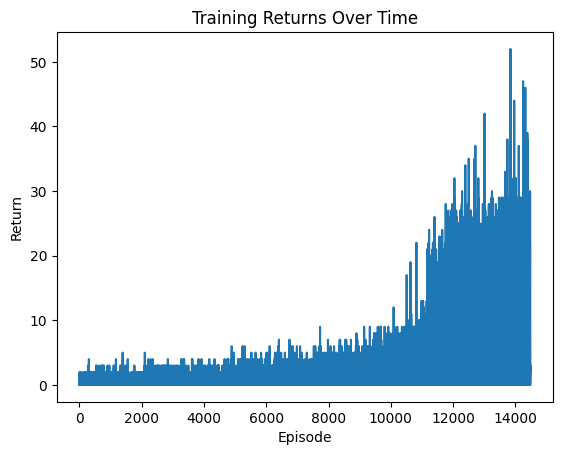

In [23]:
qnet, training_info = train_double_dqn(env, num_steps=500_000, seed=0)

plt.plot(training_info["returns"])
plt.title("Training Returns Over Time")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()

We now compare different hyperparameter choices for the learning rate, the target update period and the exploration schedule.

In each configuration, we only change one hyperparameter from the base line above.

In [24]:
def smooth_1d(x, window=5):
    if window <= 1:
        return np.asarray(x, dtype=np.float32)
    k = np.ones(window) / window
    return np.convolve(np.asarray(x, dtype=np.float32), k, mode="valid")

Running baseline: {'lr': 0.001, 'target_update': 1000, 'eps_decay_steps': 200000}
Running lower_lr: {'lr': 0.0005, 'target_update': 1000, 'eps_decay_steps': 200000}
Running slower_target: {'lr': 0.001, 'target_update': 2000, 'eps_decay_steps': 200000}
Running more_explore: {'lr': 0.001, 'target_update': 1000, 'eps_decay_steps': 300000}


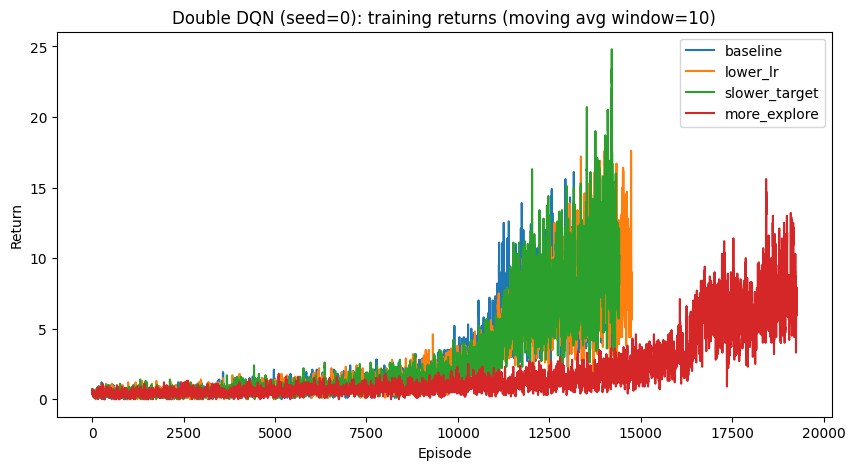

In [25]:
# Change one hyperparameter at a time from the baseline configuration
configs = [
    ("baseline",        dict(lr=1e-3, target_update=1000, eps_decay_steps=200_000)),
    ("lower_lr",        dict(lr=5e-4, target_update=1000, eps_decay_steps=200_000)),
    ("slower_target",   dict(lr=1e-3, target_update=2000, eps_decay_steps=200_000)),
    ("more_explore",    dict(lr=1e-3, target_update=1000, eps_decay_steps=300_000)),
]

seed = 0
num_steps = 500_000
smooth_window = 10

curves = {}

for name, kwargs in configs:
    print(f"Running {name}: {kwargs}")
    env = gym.make("MinAtar/Breakout-v1", disable_env_checker=True)
    qnet, info = train_double_dqn(env, num_steps=num_steps, seed=seed, **kwargs)
    env.close()

    returns = info["returns"]
    curves[name] = smooth_1d(returns, window=smooth_window)

# Plot
plt.figure(figsize=(10, 5))
for name, y in curves.items():
    plt.plot(np.arange(len(y)), y, label=name)

plt.title(f"Double DQN (seed={seed}): training returns (moving avg window={smooth_window})")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()

### Answer to Question 5: Comparison

Evaluating seed 0...
Evaluating seed 1...
Evaluating seed 2...


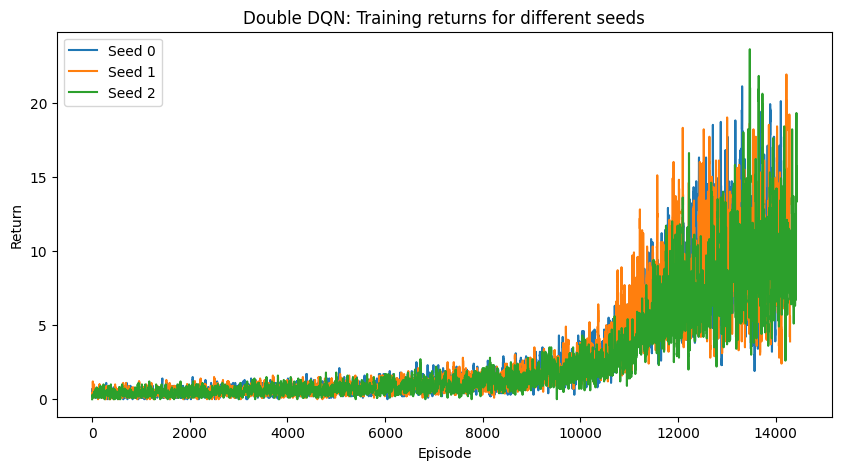

In [27]:
seeds = [0, 1, 2]
num_steps = 500_000
rewards_per_seed = []

for seed in seeds:
    print(f"Evaluating seed {seed}...")
    env = gym.make("MinAtar/Breakout-v1", disable_env_checker=True)
    qnet, info = train_double_dqn(env, num_steps=num_steps, seed=seed, verbose=False)
    rewards_per_seed.append(info["returns"])

plt.figure(figsize=(10, 5))
for i, rewards in enumerate(rewards_per_seed):
    plt.plot(smooth_1d(rewards, window=10), label=f"Seed {seeds[i]}")
plt.title("Double DQN: Training returns for different seeds")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()
    

/users/eleves-a/2022/stephane.eilles-chan-way/envs/dl_env/lib64/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


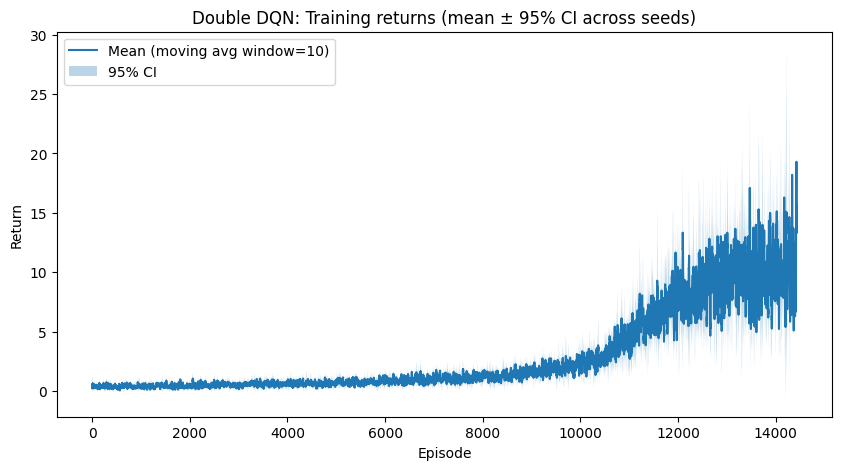

In [ ]:
window = 10
smoothed = [smooth_1d(r, window=window) for r in rewards_per_seed]

# Align lengths with NaN padding
max_len = max(len(r) for r in smoothed)
M = np.full((len(smoothed), max_len), np.nan, dtype=np.float32)
for i, r in enumerate(smoothed):
    M[i, :len(r)] = r

# Mean + 95% CI across seeds (pointwise)
mean = np.nanmean(M, axis=0)
std = np.nanstd(M, axis=0, ddof=1)
n = np.sum(~np.isnan(M), axis=0)              # number of seeds available at each episode index
se = std / np.sqrt(np.maximum(n, 1))
ci95 = 1.96 * se

episodes = np.arange(len(mean))


plt.figure(figsize=(10, 5))

# mean + CI
plt.plot(episodes, mean, label=f"Mean (moving avg window={window})")
plt.fill_between(episodes, mean - ci95, mean + ci95, alpha=0.3, label="95% CI")

plt.title("Double DQN: Training returns (mean ± 95% CI across seeds)")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()

In [31]:
eval_env = gym.make("MinAtar/Breakout-v1", disable_env_checker=True)

eval_returns, eval_steps = evaluate_policy_q(eval_env, qnet, n_episodes=1000)
print(f"Evaluation over 1000 episodes: Mean Return = {eval_returns.mean():.2f} +/- {eval_returns.std():.2f}")
print(f"Eval mean steps: {np.mean(eval_steps):.2f} +/- {np.std(eval_steps):.2f}")

Evaluation over 1000 episodes: Mean Return = 13.29 +/- 13.55
Eval mean steps: 173.61 +/- 204.83


Compared to the tabular Q-learning agent from Part 2, the Double DQN method is less sample-efficient at the beginning: the training curve stays near zero for a long warm-up period before sharply improving once sufficient experience is accumulated in the replay buffer. 

However, it achieves substantially higher final performance. In evaluation, Double DQN reaches a mean return of 13.29 ± 13.55 with 173.61 ± 204.83 steps, whereas tabular Q-learning achieves only 4.21 ± 2.30 return with 51.38 ± 25.06 steps. This improvement is expected because the deep agent learns directly from the full $10\times10\times4$ observation (capturing brick layout and spatial structure), while the classical method relies on a compact hand-crafted state that induces aliasing. 

In terms of training stability, Double DQN shows higher variability (larger confidence intervals and occasional spikes), reflecting the instability of deep RL, although the use of replay, a target network, and Huber loss helps mitigate divergence.

---

## Part 4: Policy Interpretation [8 marks]

Analyze the behavior of your trained agents.

### Questions to Address

1. **Qualitative behavior**: Report a video of your trained agent playing. Describe its strategy in words. Does it behave similarly to the heuristic, or has it learned a different approach?

2. **State-action analysis**: For your best policy, visualize what actions it selects in different states.

3. **Failure cases**: Identify situations where the policy makes poor decisions. What do these cases have in common?

4. **Comparison across methods**: Do your classical and deep RL methods learn similar or different strategies? If not, why ?

In [ ]:
qnet, info = train_double_dqn(env, num_steps=500_000, seed=0, verbose=False)

In [32]:
def make_policy_fn(qnet, device):
    @torch.no_grad()
    def policy_fn(observation, num_actions):
        qnet.eval()
        state = preprocess_obs(observation).unsqueeze(0).to(device)
        q_values = qnet(state)
        action = int(torch.argmax(q_values, dim=1).item())
        return action
    return policy_fn

In [34]:
frames, reward, steps = run_episode_with_frames(env_visual, make_policy_fn(qnet, device), max_steps=5000)
print(f"Episode: Reward = {reward}, Steps = {steps}") 
anim = animate_episode(frames, interval=100)
HTML(anim.to_jshtml())

Episode: Reward = 28, Steps = 312


### Answer to Question 1: Qualitative behavior
In the gameplay video, the Double DQN agent reliably keeps the ball in play and, importantly, sometimes adopts a high-reward tactic that the heuristic and the tabular Q-learning policy rarely achieve: it “aims” the ball into gaps so that it can pass above the brick wall and clear many bricks quickly. 

Unlike the heuristic, the agent does not constantly track the ball’s current horizontal position. Instead, it sometimes stays relatively still while the ball is rising and only starts moving when the ball is descending, suggesting it has learned that paddle adjustments are most critical near the interception phase. 

Its movement also appears to be more “predictive” than the heuristic: it reacts to the direction of the ball (e.g., if the ball is currently on the right but moving left, it may move left rather than chasing the ball’s instantaneous position). Overall, it has learned a different and more strategic approach than the heuristic controller.

### Answer to Question 2: State-action analysis
To analyze the learned policy, we fix an interpretable slice of the state space and query the trained network to see which action it chooses. In practice, we generate a grid of synthetic $10\times10\times4$ observations where we control variables such as the relative paddle–ball position $x_{\text{rel}}$ and the ball’s direction $dx$ (optionally fixing $y_{\text{ball}}$ and $dy$). For each grid point, we compute the greedy action $a=\arg\max_a Q(s,a)$ and visualize the result as a heatmap color-coded by action (stay / left / right), comparing separate maps for $dy=+1$ (descending) and $dy=-1$(ascending).

In [37]:
from matplotlib.colors import ListedColormap, BoundaryNorm

ACTION_NAMES = {0: "STAY", 1: "LEFT", 2: "RIGHT"}

def make_synthetic_obs(ball_x, ball_y, paddle_x, dx, dy,
                       H=10, W=10, C=4, paddle_y=9):
    """
    Observation binaire (10,10,4) :
    channel 0 = paddle, 1 = ball, 2 = trail, 3 = bricks (ici vides)
    trail placé à (ball_x - dx, ball_y - dy) si valide.
    """
    obs = np.zeros((H, W, C), dtype=np.float32)

    ball_x = int(np.clip(ball_x, 0, W-1))
    ball_y = int(np.clip(ball_y, 0, H-1))
    paddle_x = int(np.clip(paddle_x, 0, W-1))
    paddle_y = int(np.clip(paddle_y, 0, H-1))

    obs[paddle_y, paddle_x, 0] = 1.0
    obs[ball_y, ball_x, 1] = 1.0

    tx = int(ball_x - dx)
    ty = int(ball_y - dy)
    if 0 <= tx < W and 0 <= ty < H:
        obs[ty, tx, 2] = 1.0

    return obs

def plot_state_action_heatmap(policy_fn, num_actions=3, y_ball=6, dy=1, ball_x_ref=5):
    x_rel_values = np.arange(-9, 10)   # -9..9
    dx_values = [-1, 1]                # si tu veux enlever dx=0 (sinon mets [-1,0,1])

    A = np.zeros((len(dx_values), len(x_rel_values)), dtype=np.int64)

    for i, dx in enumerate(dx_values):
        for j, x_rel in enumerate(x_rel_values):
            paddle_x = ball_x_ref + x_rel
            obs = make_synthetic_obs(
                ball_x=ball_x_ref, ball_y=y_ball,
                paddle_x=paddle_x,
                dx=dx, dy=dy
            )
            A[i, j] = policy_fn(obs, num_actions)

    # --- Colormap fixe: 0=STAY blanc, 1=LEFT bleu, 2=RIGHT rouge ---
    cmap = ListedColormap(["white", "blue", "red"])
    norm = BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5], ncolors=cmap.N)

    plt.figure(figsize=(10, 3.8))
    im = plt.imshow(A, aspect="auto", interpolation="nearest", cmap=cmap, norm=norm)

    # Colorbar avec labels propres
    cbar = plt.colorbar(im, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(["STAY", "LEFT", "RIGHT"])

    plt.xticks(np.arange(len(x_rel_values)), x_rel_values)
    plt.yticks(np.arange(len(dx_values)), dx_values)
    plt.xlabel(r"$x_{rel} = x_{paddle} - x_{ball}$ (ball_x fixed)")
    plt.ylabel("dx (ball horizontal direction)")
    plt.title(f"Greedy action heatmap (y_ball={y_ball}, dy={dy})")

    plt.tight_layout()
    plt.show()

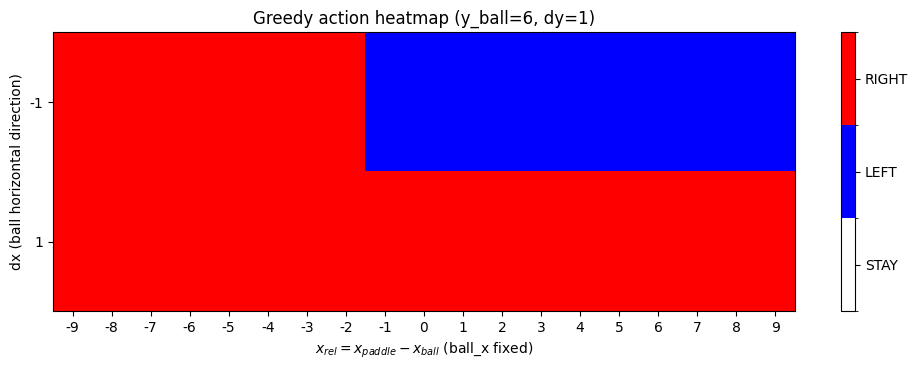

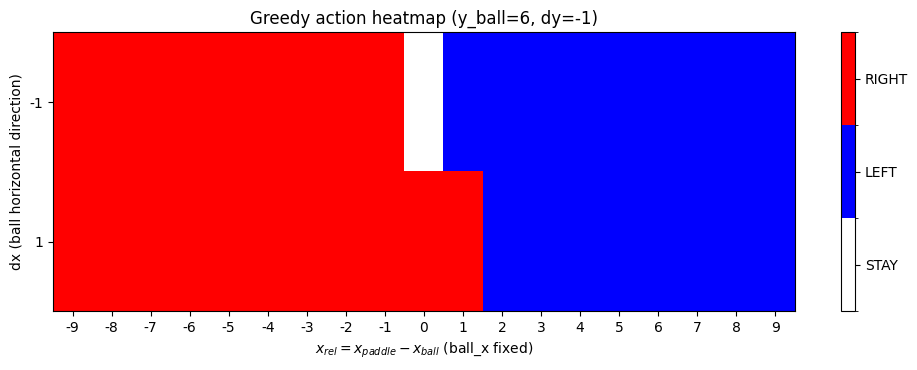

In [39]:
policy_fn = make_policy_fn(qnet, device)
plot_state_action_heatmap(policy_fn, num_actions=env.action_space.n, y_ball=6, dy=1,  ball_x_ref=5)
plot_state_action_heatmap(policy_fn, num_actions=env.action_space.n, y_ball=6, dy=-1, ball_x_ref=5)

The state–action heatmaps reveal a clear dependence of the learned policy on the ball’s vertical motion. 

When the ball is rising ($dy=-1$), the agent behaves mostly like a tracking controller: its action is primarily driven by the relative horizontal position $x_{\text{rel}}=x_{\text{paddle}}-x_{\text{ball}}$, moving right when it is left of the ball and left when it is right of the ball. 

In contrast, when the ball is descending ($dy=+1$), the policy becomes more directional and “predictive”. The chosen action depends less on $x_{\text{rel}}$ and more on the ball’s horizontal direction dx, moving in the same direction as the ball (right if $dx=+1$, left if $dx=-1$). 

### Answer to Question 3: Failure cases
The main failure cases occur when the ball’s trajectory changes abruptly during the descent phase, for example after bouncing off a side wall while moving downward, so that the paddle’s late movement is no longer sufficient to reach the new landing position. 

Another recurring failure happens when the paddle is stuck near one side (for example far left) while the ball rises diagonally toward the opposite side. Because the policy often does not move much during the rising phase, it starts repositioning only once the ball begins to descend; if the descent is fast and far (ending near the opposite corner), the paddle cannot cross the screen in time and misses the ball. 

These failure cases share a common structure: they require early repositioning or long-horizon anticipation (moving during ascent), which the policy under-emphasizes compared to short-horizon interception.

### Answer to Question 4: Comparison across methods
The classical and deep RL methods learn noticeably different strategies. The tabular Q-learning agent, trained on a compact hand-crafted state, primarily learns a conservative “survival” behavior (keeping the ball in play) and lacks the information needed to intentionally aim at specific brick patterns or gaps. 

In contrast, the deep agent observes the full spatial grid, including the brick layout, and can therefore learn richer behaviors such as targeting openings to send the ball above the bricks. 

This difference is expected: the classical method suffers from state aliasing due to its reduced representation (many distinct situations map to the same state), while the CNN-based deep RL method can exploit spatial structure and direction-dependent patterns to learn a more predictive, goal-directed policy.

---

## Part 5: Improving Performance [4 marks]

Investigate techniques to improve your agents' performance and training stability.

### Requirements

Choose **at least two** of the following directions:

- **Ablation study**: Remove or modify components of your algorithm and measure the impact.
- **Variance reduction**: Implement and compare techniques to reduce gradient variance.
- **Regularization**: Experiment with regularization techniques and analyze their effects.
- **Hyperparameter sensitivity**: Systematically vary hyperparameters and report their effects.
- **Exploration strategies**: Compare different exploration methods. [At least 2]

### Instructions for the report

For each investigation:
- State your hypothesis before running experiments
- Present results with appropriate visualizations
- Discuss whether results matched your expectations and explain any surprises
- Discuss the limitations and their probable solutions of your proposed approach.

### Answer

We choose to investigate the following three directions: exploration strategies, ablation studies and additional stabilization techniques.

#### Exploration strategies
In our training curves, the Deep RL agent exhibits a long “warm-up” phase where returns remain close to zero before improving sharply. This behavior is typical in sparse-reward environments such as Breakout, where the agent must discover useful trajectories before learning can propagate value estimates. To address this, we investigate alternative exploration strategies beyond standard $\epsilon$-greedy. We compare the following methods:
- **$\epsilon$-greedy**: the baseline method where the agent selects a random action with probability $\epsilon$ and the greedy action otherwise.
- **Boltzmann exploration**: where actions are sampled from a softmax distribution over Q-values, controlled by a temperature parameter $T$.
- **Sticky $\epsilon$-greedy**: a variant where the agent repeats the last action with probability $p_{\text{sticky}}$ to encourage more consistent exploration, otherwise it follows the standard $\epsilon$-greedy policy.

Hypothesis:
- Softmax exploration will improve early learning (better sample efficiency) by biasing exploration toward actions with higher estimated value, reducing the time spent taking uniformly random actions.
- $\epsilon$-greedy may remain competitive later in training, but can be less efficient early on in sparse-reward settings because random actions are often uninformative.
- Sticky $\epsilon$-greedy will improve early learning (better sample efficiency) by producing temporally correlated action sequences, enabling more consistent exploration of trajectories than step-wise random actions in a sparse-reward environment.

#### Ablation studies
Our Double DQN implementation uses several stabilizing components (replay buffer, target network, and Double DQN targets). We perform ablations to quantify the impact of each component and demonstrate that these “stabilization tricks” are necessary for reliable learning.

Hypothsesis:
- Removing the target network will significantly reduce training stability because the TD target becomes highly non-stationary, leading to larger oscillations and potentially divergence.
- Removing the replay buffer will increase gradient variance and slow down learning, as updates are performed on highly correlated samples.
- Replacing Double DQN with standard DQN will increase overestimation bias and typically reduce final performance and/or stability.

#### Additional stabilization techniques
In addition to the previous DQN stabilizations, we investigate the impact of one additional technique. We choose to clip the gradient norm to a fixed value (e.g., 10) to prevent excessively large updates that can destabilize training.

Hypothesis:
- Gradient clipping will improve stability by preventing occasional large TD errors from producing excessively large parameter updates, reducing catastrophic spikes in training and making learning more robust across training steps.


In [40]:
@torch.no_grad()
def select_action_boltzmann(q_online, state, n_actions, T, device):
    q = q_online(state.unsqueeze(0).to(device)).squeeze(0)  # (A,)
    q = q - q.max()  
    logits = q / max(T, 1e-8)
    probs = torch.softmax(logits, dim=0).detach().cpu().numpy()
    return int(np.random.choice(n_actions, p=probs))

def temperature_by_step(step, T_start=1.0, T_end=0.05, decay_steps=200_000):
    frac = min(step / decay_steps, 1.0)
    return T_start + frac * (T_end - T_start)

@torch.no_grad()
def select_action_sticky(q_online, state, n_actions, eps, device, last_action, p_sticky):
    if (last_action is not None) and (random.random() < p_sticky):
        return int(last_action)
    return select_action(q_online, state, n_actions, eps, device)

In [41]:
def train_new(
    env,
    num_steps=300_000,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_size=50_000,
    learning_starts=1_000,
    train_freq=4,
    target_update=1_000,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=200_000,
    max_episode_steps=5000,
    seed=0,
    device=None,
    verbose=False,
    # exploration
    exploration="epsilon",   # "epsilon" | "boltzmann" | "sticky"
    T_start=1.0, T_end=0.05, T_decay_steps=200_000,
    p_sticky=0.15,
    # ablations
    use_replay=True,
    use_target=True,
    use_double=True,
    # grad clipping
    grad_clip=None,         
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    n_actions = env.action_space.n

    q_online = QNet(n_actions).to(device)

    q_target = None
    if use_target:
        q_target = QNet(n_actions).to(device)
        q_target.load_state_dict(q_online.state_dict())
        q_target.eval()

    optimizer = optim.Adam(q_online.parameters(), lr=lr)
    replay = ReplayBuffer(buffer_size) if use_replay else None

    # logging
    episode_returns, episode_lengths = [], []
    n_ep = 0

    obs, info = env.reset(seed=seed)
    state = preprocess_obs(obs)
    ep_return, ep_len = 0.0, 0
    global_step = 0

    last_transition = None
    last_action = None

    while global_step < num_steps:
        eps = epsilon_by_step(global_step, eps_start, eps_end, eps_decay_steps)

        # action selection with different exploration strategies
        if exploration == "epsilon":
            action = select_action(q_online, state, n_actions, eps, device)

        elif exploration == "boltzmann":
            T = temperature_by_step(global_step, T_start, T_end, T_decay_steps)
            action = select_action_boltzmann(q_online, state, n_actions, T, device)

        elif exploration == "sticky":
            action = select_action_sticky(q_online, state, n_actions, eps, device, last_action, p_sticky)

        else:
            raise ValueError(f"Unknown exploration: {exploration}")

        last_action = action

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        next_state = preprocess_obs(next_obs)

        if use_replay:
            replay.push(state, action, reward, next_state, float(done))
        else:
            last_transition = (state, action, reward, next_state, float(done))

        state = next_state
        ep_return += reward
        ep_len += 1
        global_step += 1

        # episode end
        if done or ep_len >= max_episode_steps:
            episode_returns.append(ep_return)
            episode_lengths.append(ep_len)
            n_ep += 1

            obs, info = env.reset(seed=seed+n_ep)  # different seed for different episodes
            state = preprocess_obs(obs)
            ep_return, ep_len = 0.0, 0
            last_transition = None
            last_action = None

        #training step
        if (global_step % train_freq == 0) and (global_step >= learning_starts):
            if use_replay:
                if len(replay) < learning_starts:
                    continue
                s, a, r, s2, d = replay.sample(batch_size, device)
            else:
                if last_transition is None:
                    continue
                s0, a0, r0, s20, d0 = last_transition
                s  = s0.unsqueeze(0).to(device)
                s2 = s20.unsqueeze(0).to(device)
                a  = torch.tensor([a0], dtype=torch.long, device=device).unsqueeze(1)
                r  = torch.tensor([r0], dtype=torch.float32, device=device).unsqueeze(1)
                d  = torch.tensor([d0], dtype=torch.float32, device=device).unsqueeze(1)

            q_sa = q_online(s).gather(1, a)

            q_eval = q_target if use_target else q_online

            with torch.no_grad():
                if use_double:
                    a_star = torch.argmax(q_online(s2), dim=1, keepdim=True)
                    q_next = q_eval(s2).gather(1, a_star)
                else:
                    q_next = torch.max(q_eval(s2), dim=1, keepdim=True).values

                y = r + gamma * (1.0 - d) * q_next

            loss = F.smooth_l1_loss(q_sa, y)

            optimizer.zero_grad()
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(q_online.parameters(), grad_clip)
            optimizer.step()

        # target network update
        if use_target and (global_step % target_update == 0):
            q_target.load_state_dict(q_online.state_dict())

        if verbose and (global_step % 10_000 == 0):
            print(f"Step {global_step}/{num_steps} | eps={eps:.3f} | last ep_return={ep_return:.2f}")

    return q_online, {"returns": np.array(episode_returns), "lengths": np.array(episode_lengths)}

In [42]:
BASE = dict(
    exploration="epsilon",
    use_replay=True, use_target=True, use_double=True,
    grad_clip=None,
    lr=1e-3, target_update=1000,
    eps_start=1.0, eps_end=0.05, eps_decay_steps=200_000,
)

configs = [
    ("baseline", dict(BASE)),

    # exploration strategies 
    ("boltzmann", dict(BASE, exploration="boltzmann", T_start=1.0, T_end=0.05, T_decay_steps=200_000)),
    ("sticky_eps", dict(BASE, exploration="sticky", p_sticky=0.15)),

    # ablations
    ("no_target", dict(BASE, use_target=False)),
    ("no_replay", dict(BASE, use_replay=False)),
    ("DQN_not_double", dict(BASE, use_double=False)),

    # gradient clipping
    ("with_grad_clip", dict(BASE, grad_clip=10.0)),
]


Running baseline
{'exploration': 'epsilon', 'use_replay': True, 'use_target': True, 'use_double': True, 'grad_clip': None, 'lr': 0.001, 'target_update': 1000, 'eps_start': 1.0, 'eps_end': 0.05, 'eps_decay_steps': 200000}
Eval (1000 eps) return: 17.79 ± 13.67 | steps: 188.42 ± 172.65

Running boltzmann
{'exploration': 'boltzmann', 'use_replay': True, 'use_target': True, 'use_double': True, 'grad_clip': None, 'lr': 0.001, 'target_update': 1000, 'eps_start': 1.0, 'eps_end': 0.05, 'eps_decay_steps': 200000, 'T_start': 1.0, 'T_end': 0.05, 'T_decay_steps': 200000}
Eval (1000 eps) return: 18.72 ± 14.65 | steps: 209.90 ± 181.08

Running sticky_eps
{'exploration': 'sticky', 'use_replay': True, 'use_target': True, 'use_double': True, 'grad_clip': None, 'lr': 0.001, 'target_update': 1000, 'eps_start': 1.0, 'eps_end': 0.05, 'eps_decay_steps': 200000, 'p_sticky': 0.15}
Eval (1000 eps) return: 17.19 ± 12.07 | steps: 193.38 ± 151.81

Running no_target
{'exploration': 'epsilon', 'use_replay': True, '

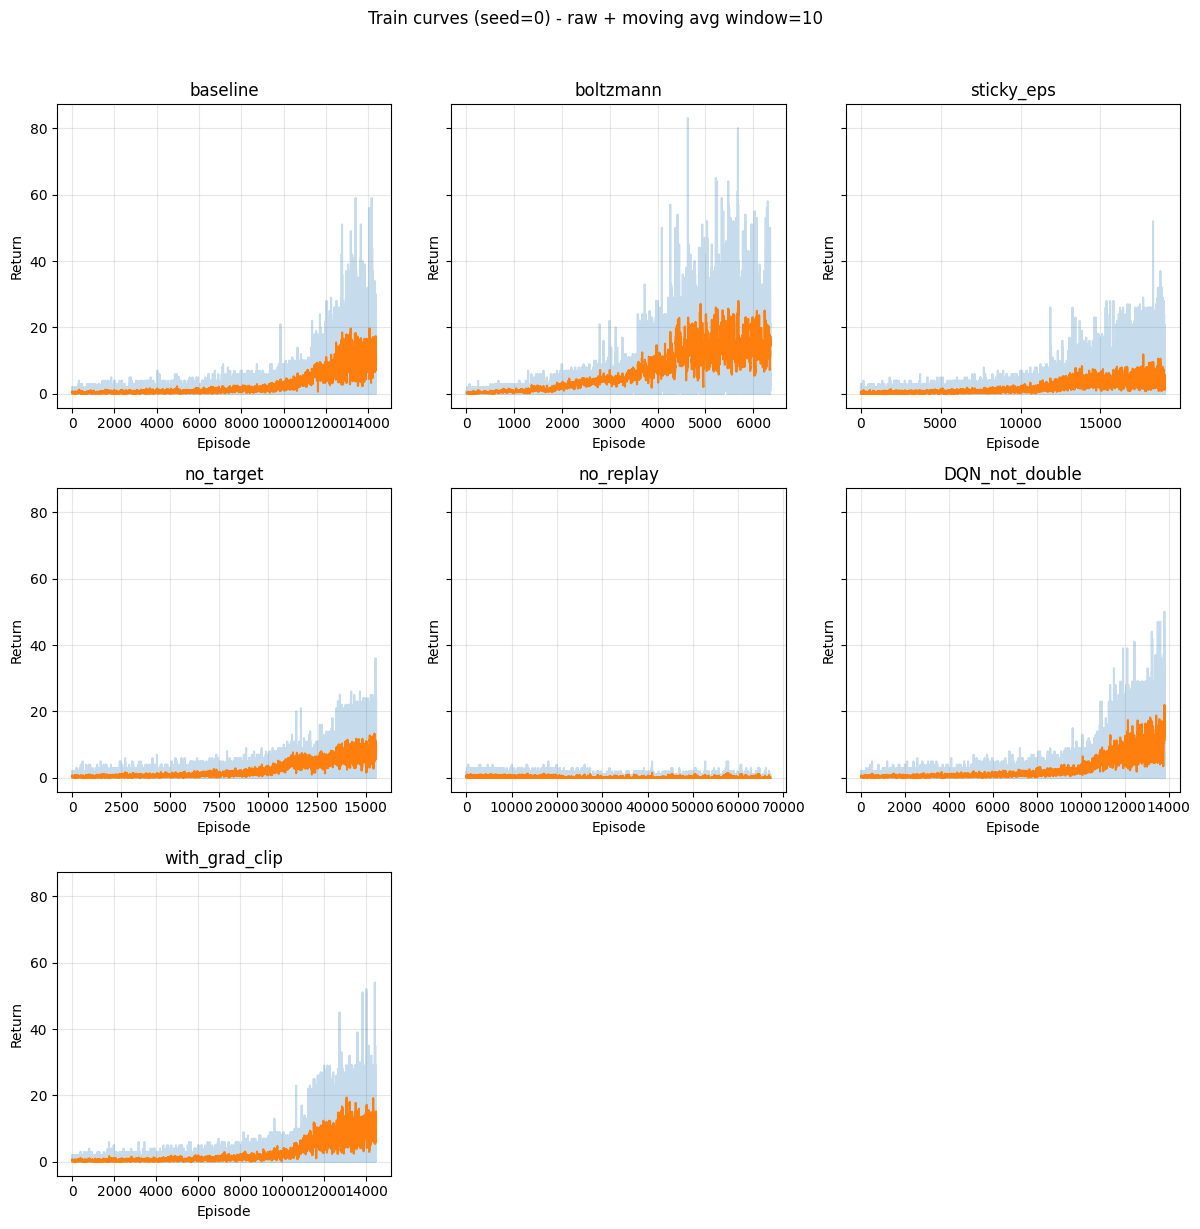


=== Evaluation summary ===
baseline       | Return 17.79 ± 13.67 | Steps 188.42 ± 172.65
boltzmann      | Return 18.72 ± 14.65 | Steps 209.90 ± 181.08
sticky_eps     | Return 17.19 ± 12.07 | Steps 193.38 ± 151.81
no_target      | Return 13.33 ± 9.05 | Steps 136.28 ± 88.39
no_replay      | Return 0.01 ± 0.10 | Steps 6.10 ± 0.99
DQN_not_double | Return 16.16 ± 13.39 | Steps 211.05 ± 225.28
with_grad_clip | Return 16.56 ± 11.51 | Steps 172.40 ± 127.16


In [ ]:
seed = 0
num_steps = 500_000
smooth_window = 10

trained = {}           # name -> qnet
episode_rewards = {}   # name -> raw episode returns 
train_curves = {}      # name -> smoothed episode returns
eval_table = []        # rows

for name, cfg in configs:
    print(f"\nRunning {name}\n{cfg}")

    env = gym.make("MinAtar/Breakout-v1", disable_env_checker=True)
    qnet, info = train_new(env, num_steps=num_steps, seed=seed, verbose=False, **cfg)
    env.close()

    trained[name] = qnet

    # store raw episode returns for this config
    episode_rewards[name] = info["returns"]  

    # also store a smoothed version for plotting
    train_curves[name] = smooth_1d(info["returns"], window=smooth_window)

    # Evaluation greedy on 1000 episodes
    eval_env = gym.make("MinAtar/Breakout-v1", disable_env_checker=True)
    eval_returns, eval_steps = evaluate_policy_q(eval_env, qnet, n_episodes=1000, seed=123)
    eval_env.close()

    row = {
        "name": name,
        "eval_return_mean": float(np.mean(eval_returns)),
        "eval_return_std": float(np.std(eval_returns)),
        "eval_steps_mean": float(np.mean(eval_steps)),
        "eval_steps_std": float(np.std(eval_steps)),
    }
    eval_table.append(row)

    print(f"Eval (1000 eps) return: {row['eval_return_mean']:.2f} ± {row['eval_return_std']:.2f} | "
          f"steps: {row['eval_steps_mean']:.2f} ± {row['eval_steps_std']:.2f}")

# Plot (raw + smoothed) in subplots 
names = list(train_curves.keys())
n = len(names)

ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), sharex=False, sharey=True)
axes = np.array(axes).reshape(-1)

for i, name in enumerate(names):
    ax = axes[i]

    raw = np.asarray(episode_rewards[name], dtype=np.float32)
    sm  = np.asarray(train_curves[name], dtype=np.float32)

    # raw (light) + smoothed (bold)
    ax.plot(np.arange(len(raw)), raw, alpha=0.25)
    ax.plot(np.arange(len(sm)) + (smooth_window - 1), sm)  # align x with end of window

    ax.set_title(name)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Return")
    ax.grid(True, alpha=0.3)

for j in range(n, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Train curves (seed={seed}) - raw + moving avg window={smooth_window}", y=1.02)
plt.tight_layout()
plt.show()

# Print comparison table
print("\n=== Evaluation summary ===")
for r in eval_table:
    print(f"{r['name']:<14} | Return {r['eval_return_mean']:.2f} ± {r['eval_return_std']:.2f} "
          f"| Steps {r['eval_steps_mean']:.2f} ± {r['eval_steps_std']:.2f}")

The light blue curves are raw returns per episode, while the orange curves are smoothed returns (moving average with window size 10) to better visualize trends.

**Boltzmann exploration**:
Boltzmann exploration achieves a slightly higher evaluation return ($18.72 ± 14.65$ vs $17.79 ± 13.67$) and longer episodes on average ($209.90 ± 181.08$ vs $188.42 ± 172.65$). 
The training curves also show a shorter warm-up before learning accelerates, which is consistent with the idea that Boltzmann biases exploration toward actions with higher estimated value and can therefore improve early learning. 
However, Boltzmann remains sensitive to the temperature schedule T. If T is too high the policy becomes close to uniform random, while if T is too low it becomes nearly greedy and may fail to explore sufficiently. In our setting, the chosen schedule appears to work well and yields slightly better final performance than the baseline.

**Sticky $\epsilon$-greedy**:
Sticky $\epsilon$-greedy remains roughly comparable to standard $\epsilon$-greedy in evaluation ($17.19 ± 12.07$ vs $17.79 ± 13.67$). Temporally correlated exploration can help by producing more coherent trajectories, but it can also introduce inertia by repeating the previous action even when the greedy choice would switch. Here, these effects largely balance out, leading to similar performance rather than a clear improvement.

**No target network**: 
Removing the target network significantly degrades performance ($13.33 ± 9.05$ vs $17.79 ± 13.67$) and reduces episode length ($136.28 ± 88.39$ steps). This supports our hypothesis: without a target network, the TD target becomes highly non-stationary (the network is chasing a moving target), which reduces training stability and leads to a weaker policy. The target network is therefore an important stabilizer.

**No replay buffer**:
Performance collapses without replay ($0.01 ± 0.10$, ~6 steps), meaning the agent essentially does not learn. This strongly confirms our hypothesis: without replay, updates are based on highly correlated transitions, increasing gradient variance and preventing effective value propagation in this sparse-reward environment. Replay is crucial for breaking correlations and reusing informative experiences.

**No Double DQN**:
Standard DQN (no Double) achieves a similar, slightly lower evaluation return than the baseline ($16.16 ± 13.39$ vs $17.79 ± 13.67$). This is consistent with Double DQN’s role: it primarily reduces overestimation bias and often improves robustness rather than guaranteeing large gains in every single run. On a single seed and finite training budget, the difference can be modest. However on the training curve, Double DQN tends to produce smoother learning with fewer extreme spikes, while standard DQN can show higher variability due to maximization bias.

**Gradient clipping**:
Gradient clipping yields a slightly lower evaluation return than the baseline ($16.56 ± 11.51$ vs $17.79 ± 13.67$). This suggests that, in our setting, clipping may be somewhat restrictive and can slow down learning by limiting large but potentially useful updates when TD errors are high. However, clipping can still be beneficial for robustness: it typically reduces the risk of occasional unstable updates, leading to smoother training curves even if the final performance is marginally lower.

---

## Part 6: Generalization to Other Environments [5 marks]

Test whether your methods transfer to other MinAtar games: Asterix, Freeway, Seaquest, and Space Invaders.

### Questions to Address

1. **Direct transfer**: Apply your best Breakout agent (without retraining) to another game. Does it perform better than random? Why or why not?

2. **Retraining**: Train your deep RL method on at least one other MinAtar game. Does it achieve similar performance relative to the random baseline? If performance differs, explain why.

3. **Architecture/hyperparameter transfer**: Can you use the same configuration across games, or do different games require different configurations?

4. **Game difficulty**: Which games are easier or harder to learn? Relate this to environment properties.


### Answer to Question 1: Direct transfer

First we retrain our best configuration on Breakout, then we apply it to the other games. We report the evaluation results in the table below.

In [ ]:
env_breakout = gym.make("MinAtar/Breakout-v1", disable_env_checker=True)
best_qnet, info = train_new(env_breakout, num_steps=500000, seed=0, verbose=False, exploration="boltzmann", T_start=1.0, T_end=0.05, T_decay_steps=200_000)
eval_returns, eval_steps = evaluate_policy_q(env_breakout, best_qnet, n_episodes=1000, seed=123)
print(f"Best config evaluation over 1000 episodes: Mean Return = {eval_returns.mean():.2f} +/- {eval_returns.std():.2f}")
print(f"Eval mean steps: {np.mean(eval_steps):.2f} +/- {np.std(eval_steps):.2f}")

Best config evaluation over 1000 episodes: Mean Return = 18.66 +/- 14.56
Eval mean steps: 190.10 +/- 152.75


We then compare the performance of the directly transferred agent to a random policy on each game. The results show that the directly transferred agent performs better than random on Asterix and Freeway, but not on Seaquest and Space Invaders.

In [16]:
env_asterix = gym.make("MinAtar/Asterix-v1", disable_env_checker=True)

num_episodes = 1000

random_rewards, random_steps = evaluate_policy(env_asterix, random_policy, num_episodes)
print(f"Random Policy:")
print(f"  Reward: {random_rewards.mean():.2f} +/- {random_rewards.std():.2f}")
print(f"  Steps:  {random_steps.mean():.2f} +/- {random_steps.std():.2f}")

best_break_rewards, best_break_steps = evaluate_policy_q(env_asterix, best_qnet, n_episodes=num_episodes)
print(f"\nBest Breakout Q-Learning Policy:")
print(f"  Reward: {best_break_rewards.mean():.2f} +/- {best_break_rewards.std():.2f}")
print(f"  Steps:  {np.mean(best_break_steps):.2f} +/- {np.std(best_break_steps):.2f}")

Random Policy:
  Reward: 0.49 +/- 0.85
  Steps:  64.70 +/- 39.14



Best Breakout Q-Learning Policy:
  Reward: 0.49 +/- 0.84
  Steps:  99.10 +/- 63.19


Applying our Breakout-trained agent directly to Asterix without retraining does not improve performance over random: both achieve the same mean return (0.49). Although the transferred agent survives longer on average (99 vs. 65 steps), this does not translate into higher reward. This is expected because the policy and features learned in Breakout are task-specific and do not generalize to Asterix’s different dynamics and reward structure.

### Answer to Question 2: Retraining
We retrain our deep RL method (Double DQN with the best hyperparameters found for Breakout) on Asterix.

In [17]:
qnet_asterix, info_asterix = train_new(env_asterix, num_steps=500000, seed=0, verbose=False, exploration="boltzmann", T_start=1.0, T_end=0.05, T_decay_steps=200_000)

qnet_asterix_rewards, qnet_asterix_steps = evaluate_policy_q(env_asterix, qnet_asterix, n_episodes=num_episodes)
print(f"\nQ-Learning Policy trained on Asterix:")
print(f"  Reward: {qnet_asterix_rewards.mean():.2f} +/- {qnet_asterix_rewards.std():.2f}")
print(f"  Steps:  {np.mean(qnet_asterix_steps):.2f} +/- {np.std(qnet_asterix_steps):.2f}")


Q-Learning Policy trained on Asterix:
  Reward: 0.53 +/- 0.88
  Steps:  102.87 +/- 64.81


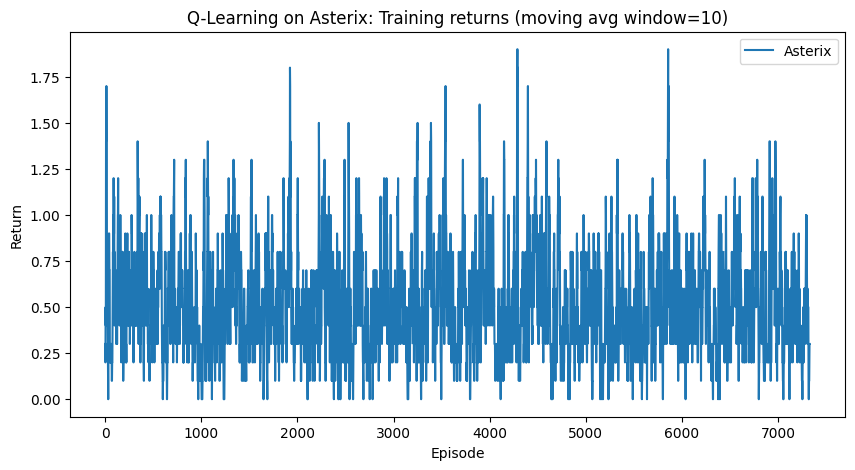

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(smooth_1d(info_asterix["returns"], window=10), label="Asterix")
plt.title("Q-Learning on Asterix: Training returns (moving avg window=10)")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()

After retraining our deep RL agent on Asterix, performance improves only marginally over the random baseline. The mean return increases from 0.49 (random) to 0.53 (trained), with very similar variance, while the trained agent survives longer on average (102.9 vs 64.7 steps). Overall, this indicates that retraining does not yield a large performance gap relative to random on Asterix under our current training setup. 

One explanation is that Asterix requires different, more precise behaviors to consistently collect rewards, and the reward signal can be relatively sparse or noisy at the beginning of training. With the same architecture and hyperparameters tuned for Breakout, the agent may learn a safer survival behavior (longer episodes) without reliably converting it into higher scoring. Further tuning (e.g., exploration, learning rate, or longer training) may be needed to achieve a stronger advantage over random.


### Answer to Question 3: Architecture/hyperparameter transfer
Across MinAtar games, the architecture is partially transferable but not always completely and directly. While all games use a $10\times10$ grid, the number of channels differs, so the CNN input layer must match the observation shape. For example, Breakout and Asterix use $10\times10\times4$, but Freeway uses $10\times10\times7$, Space Invaders $10\times10\times6$, and Seaquest $10\times10\times10$. Therefore, the first convolutional layer must be adapted to the correct input channel count, and the final layer must also be adapted to the game’s action space size $|\mathcal{A}|$. In our code, the output head is already set using env.action_space.n, but the input channels would need to be parameterized similarly (e.g., in_channels = obs.shape[-1]) to reuse the same configuration across all games.

In terms of hyperparameters, as we saw with Asterix, the same configuration that worked well for Breakout does not necessarily yield strong performance on another game. Different games have different dynamics, reward structures, and exploration challenges, so hyperparameters such as learning rate, exploration, and target update frequency may need to be tuned separately for each game to achieve good performance.


### Answer to Question 4: Game difficulty

In [16]:
class QNetFlexible(nn.Module):
    def __init__(self, in_channels, n_actions, hidden_dim=256):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 10 * 10, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, n_actions)

    def forward(self, x):
        # x: (B, C, 10, 10)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)
    
def preprocess_obs_flexible(obs):
    x = np.transpose(obs, (2, 0, 1)).astype(np.float32)
    return torch.from_numpy(x)

import random
import numpy as np
import torch
import torch.optim as optim
import torch.nn.functional as F

def train_new_flexible(
    env,
    num_steps=300_000,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_size=50_000,
    learning_starts=1_000,
    train_freq=4,
    target_update=1_000,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=200_000,
    max_episode_steps=5000,
    seed=0,
    device=None,
    verbose=False,
    # exploration
    exploration="epsilon",   # "epsilon" | "boltzmann" | "sticky"
    T_start=1.0, T_end=0.05, T_decay_steps=200_000,
    p_sticky=0.15,
    # ablations
    use_replay=True,
    use_target=True,
    use_double=True,
    # grad clipping
    grad_clip=None,
    # network
    hidden_dim=256,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # first reset to infer observation channels
    obs, info = env.reset(seed=seed)
    in_channels = obs.shape[-1]
    n_actions = env.action_space.n

    q_online = QNetFlexible(in_channels=in_channels, n_actions=n_actions, hidden_dim=hidden_dim).to(device)

    q_target = None
    if use_target:
        q_target = QNetFlexible(in_channels=in_channels, n_actions=n_actions, hidden_dim=hidden_dim).to(device)
        q_target.load_state_dict(q_online.state_dict())
        q_target.eval()

    optimizer = optim.Adam(q_online.parameters(), lr=lr)
    replay = ReplayBuffer(buffer_size) if use_replay else None

    episode_returns, episode_lengths = [], []
    n_ep = 0

    state = preprocess_obs_flexible(obs)
    ep_return, ep_len = 0.0, 0
    global_step = 0

    last_transition = None
    last_action = None

    while global_step < num_steps:
        eps = epsilon_by_step(global_step, eps_start, eps_end, eps_decay_steps)

        # action selection
        if exploration == "epsilon":
            action = select_action(q_online, state, n_actions, eps, device)

        elif exploration == "boltzmann":
            T = temperature_by_step(global_step, T_start, T_end, T_decay_steps)
            action = select_action_boltzmann(q_online, state, n_actions, T, device)

        elif exploration == "sticky":
            action = select_action_sticky(q_online, state, n_actions, eps, device, last_action, p_sticky)

        else:
            raise ValueError(f"Unknown exploration: {exploration}")

        last_action = action

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        next_state = preprocess_obs_flexible(next_obs)

        if use_replay:
            replay.push(state, action, reward, next_state, float(done))
        else:
            last_transition = (state, action, reward, next_state, float(done))

        state = next_state
        ep_return += reward
        ep_len += 1
        global_step += 1

        # end of episode
        if done or ep_len >= max_episode_steps:
            episode_returns.append(ep_return)
            episode_lengths.append(ep_len)
            n_ep += 1

            obs, info = env.reset(seed=seed + n_ep) 
            state = preprocess_obs_flexible(obs)
            ep_return, ep_len = 0.0, 0
            last_transition = None
            last_action = None

        # training step
        if (global_step % train_freq == 0) and (global_step >= learning_starts):
            if use_replay:
                if len(replay) < learning_starts:
                    continue
                s, a, r, s2, d = replay.sample(batch_size, device)
            else:
                if last_transition is None:
                    continue
                s0, a0, r0, s20, d0 = last_transition
                s  = s0.unsqueeze(0).to(device)
                s2 = s20.unsqueeze(0).to(device)
                a  = torch.tensor([a0], dtype=torch.long, device=device).unsqueeze(1)
                r  = torch.tensor([r0], dtype=torch.float32, device=device).unsqueeze(1)
                d  = torch.tensor([d0], dtype=torch.float32, device=device).unsqueeze(1)

            q_sa = q_online(s).gather(1, a)

            q_eval = q_target if use_target else q_online

            with torch.no_grad():
                if use_double:
                    a_star = torch.argmax(q_online(s2), dim=1, keepdim=True)
                    q_next = q_eval(s2).gather(1, a_star)
                else:
                    q_next = torch.max(q_eval(s2), dim=1, keepdim=True).values

                y = r + gamma * (1.0 - d) * q_next

            loss = F.smooth_l1_loss(q_sa, y)

            optimizer.zero_grad()
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(q_online.parameters(), grad_clip)
            optimizer.step()

        # target update
        if use_target and (global_step % target_update == 0):
            q_target.load_state_dict(q_online.state_dict())

        if verbose and (global_step % 10_000 == 0):
            print(f"Step {global_step}/{num_steps} | eps={eps:.3f} | last ep_return={ep_return:.2f}")

    return q_online, {"returns": np.array(episode_returns), "lengths": np.array(episode_lengths)}

In [17]:
env_breakout = gym.make("MinAtar/Breakout-v1", disable_env_checker=True)
env_asterix = gym.make("MinAtar/Asterix-v1", disable_env_checker=True)
env_freeway = gym.make("MinAtar/Freeway-v1", disable_env_checker=True)
env_seaquest = gym.make("MinAtar/Seaquest-v1", disable_env_checker=True)
env_space_invaders = gym.make("MinAtar/SpaceInvaders-v1", disable_env_checker=True)

envs = {
    "Breakout": env_breakout,
    "Asterix": env_asterix,
    "Freeway": env_freeway,
    "Seaquest": env_seaquest,
    "SpaceInvaders": env_space_invaders
}

In [34]:
qnet_freeway,info_freeway = train_new_flexible(env_freeway, num_steps=500000, seed=0, verbose=False, exploration="boltzmann", T_start=1.0, T_end=0.05, T_decay_steps=200_000)
freeway_rewards, freeway_steps = evaluate_policy_q(env_freeway, qnet_freeway, n_episodes=num_episodes)
print(f"\nFreeway Q-Learning Policy:")
print(f"  Reward: {freeway_rewards.mean():.2f} +/- {freeway_rewards.std():.2f}")
print(f"  Steps:  {np.mean(freeway_steps):.2f} +/- {np.std(freeway_steps):.2f}")


Freeway Q-Learning Policy:
  Reward: 18.90 +/- 12.55
  Steps:  2501.00 +/- 0.00


In [20]:
random_rewards, random_steps = evaluate_policy(env_freeway, random_policy, num_episodes)
print(f"Freeway Random Policy:")
print(f"  Reward: {random_rewards.mean():.2f} +/- {random_rewards.std():.2f}")
print(f"  Steps:  {random_steps.mean():.2f} +/- {random_steps.std():.2f}")

Freeway Random Policy:
  Reward: 0.36 +/- 0.56
  Steps:  2501.00 +/- 0.00


In [18]:
qnet_seaquest,info_seaquest = train_new_flexible(env_seaquest, num_steps=500000, seed=0, verbose=False, exploration="boltzmann", T_start=1.0, T_end=0.05, T_decay_steps=200_000) 
seaquest_rewards, seaquest_steps = evaluate_policy_q(env_seaquest, qnet_seaquest, n_episodes=num_episodes)
print(f"\nSeaquest Q-Learning Policy:")
print(f"  Reward: {seaquest_rewards.mean():.2f} +/- {seaquest_rewards.std():.2f}")
print(f"  Steps:  {np.mean(seaquest_steps):.2f} +/- {np.std(seaquest_steps):.2f}")


Seaquest Q-Learning Policy:
  Reward: 0.33 +/- 0.60
  Steps:  171.42 +/- 69.18


In [21]:
random_rewards, random_steps = evaluate_policy(env_seaquest, random_policy, num_episodes)
print(f"Seaquest Random Policy:")
print(f"  Reward: {random_rewards.mean():.2f} +/- {random_rewards.std():.2f}")
print(f"  Steps:  {random_steps.mean():.2f} +/- {random_steps.std():.2f}")

Seaquest Random Policy:
  Reward: 0.11 +/- 0.40
  Steps:  28.09 +/- 35.03


In [19]:
qnet_space_invaders,info_space_invaders = train_new_flexible(env_space_invaders, num_steps=500000, seed=0, verbose=False, exploration="boltzmann", T_start=1.0, T_end=0.05, T_decay_steps=200_000)
space_invaders_rewards, space_invaders_steps = evaluate_policy_q(env_space_invaders, qnet_space_invaders, n_episodes=num_episodes)
print(f"\nSpace Invaders Q-Learning Policy:")
print(f"  Reward: {space_invaders_rewards.mean():.2f} +/- {space_invaders_rewards.std():.2f}")
print(f"  Steps:  {np.mean(space_invaders_steps):.2f} +/- {np.std(space_invaders_steps):.2f}")


Space Invaders Q-Learning Policy:
  Reward: 29.95 +/- 20.38
  Steps:  288.95 +/- 198.60


In [22]:
random_rewards, random_steps = evaluate_policy(env_space_invaders, random_policy, num_episodes)
print(f"Space Invaders Random Policy:")
print(f"  Reward: {random_rewards.mean():.2f} +/- {random_rewards.std():.2f}")
print(f"  Steps:  {random_steps.mean():.2f} +/- {random_steps.std():.2f}")

Space Invaders Random Policy:
  Reward: 4.02 +/- 3.24
  Steps:  62.99 +/- 51.40


Based on our retraining results, Freeway and Space Invaders are the easiest games for our agent to learn, Seaquest is intermediate, and Asterix is the hardest in our setting. Freeway shows a very large gap over random ($18.9$ vs $0.36$ return), and Space Invaders also improves strongly over random ($29.95$ vs $4.02$). 

A key common property of the games where learning works well is that the controllable object moves mainly along a single direction/axis: this is true for Freeway and Space Invaders, and it is also the case for Breakout, where the paddle only moves horizontally. This simplifies the control problem and reduces the need for complex long-horizon planning. 

In addition, these games tend to provide more frequent and directly attributable rewards (e.g., shooting enemies or reaching goals), making credit assignment easier. Seaquest improves over random but remains low in absolute reward, which is consistent with a harder environment: more channels/objects, higher dynamical complexity, and a more demanding survival component, leading to sparser or noisier learning signals. 

Finally, Asterix shows only a marginal improvement over random, suggesting that success requires more complex multi-object interactions and stronger anticipation/planning, and that the reward signal is harder to exploit with the same hyperparameters and training budget. 

Overall, games with simpler control geometry (mostly one-direction movement) and denser rewards are easier to learn, while games with richer dynamics, more objects, and delayed/sparse rewards are harder.

---

## Summary

Conclude your notebook with a brief summary of:

- Your main findings across all parts
- What worked well and what did not
- What you would try next if you had more time

Make one paragraph answering these three points for each part of the assignment.

#### Part 1: Environment Analysis
We analyzed MinAtar Breakout by describing the observation structure (grid with multiple channels), action set, sparse reward (+1 per brick), and termination condition (missing the ball), and we compared random and heuristic baselines to quantify how much simple structure already improves returns and episode length.  ￼ This part worked well to motivate later choices (state compression and the need for strong exploration/stabilization), while the main limitation is that theoretical state-space counts are only loose upper bounds because most binary grids are unreachable under the environment dynamics. With more time, we would add more systematic determinism/stochasticity checks (fixed seed + fixed action sequence reproducibility) and report additional summary statistics (e.g., fraction of zero-reward episodes and truncation behavior).

#### Part 2: Classical RL Method
We implemented tabular Q-learning with a compact hand-crafted state (relative paddle–ball position and ball motion), which made learning tractable and clearly outperformed random, but remained below the heuristic policy. The method worked well for learning a stable “keep the ball alive” behavior, but the reduced state representation caused aliasing (no brick-layout information), limiting strategic aiming and final performance. If we had more time, we would enrich the state with minimal brick information (e.g., bricks-left buckets or a local brick feature above the ball).

#### Part 3: Deep RL Method
We implemented a CNN-based Double DQN using the raw observation (channel-first), replay buffer, target network, and Huber loss, and this deep agent substantially improved over the classical method by exploiting the full spatial structure of the environment. Training worked well once performance “took off,” but it was slower and noisier than tabular learning, making stabilization and exploration schedules important. With more time, we would run more seeds to better quantify variability, tune exploration schedules per game (especially in sparse-reward regimes), and test common DQN extensions such as dueling networks or prioritized replay for better sample efficiency and stability.

#### Part 4: Policy Interpretation
We interpreted the learned policy using gameplay videos and state–action heatmaps over controlled state slices, showing that the agent’s behavior depends strongly on ball motion (e.g., more directional/intercept-like decisions when the ball is descending) and differs from the heuristic’s pure tracking strategy. This approach worked well for producing an interpretable qualitative and semi-quantitative explanation of decisions, but it is limited because low-dimensional slices (and synthetic states) cannot capture all contexts encountered in real trajectories. With more time, we would analyzed the policy's behavior according to where are the bricks left and we would perform analysis on real visited states (e.g., clustering trajectory segments) .

#### Part 5: Improving Performance
We investigated performance improvements through exploration-strategy comparisons (ε-greedy vs Boltzmann vs sticky ε-greedy) and ablation studies that demonstrated the importance of DQN stabilizers: replay was essential (removing it collapsed learning) and the target network significantly improved performance, while other components (Double vs standard DQN, gradient clipping) had smaller or configuration-dependent effects. These experiments worked well to validate the purpose of stabilization “tricks,” but conclusions are still influenced by variance and a finite training budget. With more time, we would repeat the key comparisons across more seeds, expand variance-reduction techniques (e.g., prioritized replay), and perform a more systematic sensitivity study of exploration and target-update schedules.

#### Part 6: Generalization to Other Environments
We tested transfer and retraining on other MinAtar games and found that direct transfer from Breakout does not improve reward in Asterix, while retraining with the same deep RL pipeline can generalize strongly to some games (large gains on Freeway and Space Invaders), moderately to Seaquest, and only marginally to Asterix. More generally, games with simpler control geometry (often movement largely along one axis, as in Breakout) and denser/clearer reward signals were easier to learn, whereas richer multi-object dynamics and longer-horizon credit assignment made learning harder. With more time, we would perform a larger multi-game study with multiple seeds and a small amount of per-game hyperparameter tuning (mainly exploration schedule and learning rate) to improve results on harder games like Asterix and Seaquest.